## Find interesting results in MPRAlm results
- significant positive negative numbers
- proportion of AF (variant_type) in significant positive and negative numbers
- proportion of cell-type variant (cardiac, neuro, cava or random) in significant positive and negative numbers
- proportion of enformer group in positive and negative numbers (high effect (significant), low effect (not-significant), random: more negative effects than positive effects?)

In [235]:
# !pip install pyarrow
# !python /data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/04_MPRAlm/workflow/scripts/feather_to_tsv.py --input-feather /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_local_standard_with_variant_controlsNGN2.feather --output-tsv  /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_standard_with_variant_controls_NGN2.tsv

Usage: feather_to_tsv.py [OPTIONS]
Try 'feather_to_tsv.py --help' for help.

Error: Invalid value for '--input-feather': Path '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_local_standard_with_variant_controlsNGN2.feather' does not exist.


In [16]:
import pandas as pd
import numpy as np
import yaml 
import matplotlib.pyplot as plt

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/config/config.yaml"
# config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/06_variant_analysis/config/config.yaml"
config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/global80K_config.yaml"
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

# bcMPRAlm_table = pd.read_csv(config["files"]["toptable_standard_control_table"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm_resequencing"], sep="\t")
# mpralm 
MPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_MPRAlm"], sep="\t")
MPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm"], sep="\t")
# bcMPRAlm_table = pd.read_csv(config["files"]["toptable_standard_control_table"], sep="\t")
bcMPRAlm_table_no_downsampling = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm_no_downsampling"], sep="\t")
# mpralm 
MPRAlm_table_no_downsampling = pd.read_csv(config["files"]["creating"]["toptable_MPRAlm_no_downsampling"], sep="\t")

print("%s analyzable variants"%(bcMPRAlm_table.shape[0])) # 41284 rows; low config: 42137 rows # with the 10 bc and without downsampling: 34683 
print("%s analyzable variants"%(MPRAlm_table.shape[0])) # 41284 rows; low config: 42137 rows # with the 10 bc and without downsampling: 34683 
print('without downsampling')
print("%s analyzable variants"%(bcMPRAlm_table_no_downsampling.shape[0])) # 34683 rows
print("%s analyzable variants"%(MPRAlm_table_no_downsampling.shape[0])) # 34683 rows
# remove lable from variant ID
#! TODO: ID is not unique investigate this problem
bcMPRAlm_table["ID"] = bcMPRAlm_table["variant_id"].str.split(":").str[1]
MPRAlm_table["ID"] = MPRAlm_table["variant_id"].str.split(":").str[1]


36694 analyzable variants
35039 analyzable variants
without downsampling
35039 analyzable variants
35039 analyzable variants


In [15]:
# with all variant controls (filtering for 2 barcodes per ref and alt): 41474; filtering 10 bc 34683
bcMPRAlm_table["variant_id"].nunique()

35039

In [2]:
# investigate the ID column
# check number of pipes in ID column
# sum(bcMPRAlm_table.ID.str.count(r'\|') == 3) # with all variant controls 41043
# bcMPRAlm_table.shape[0]
# => some have not the same pipe number => check pipe number distribution
bcMPRAlm_table.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID
0,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...
1,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...
2,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...
3,0.861337,0.989619,11.188733,2.500592e-27,2.190456e-23,51.127418,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...
4,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...


In [3]:
MPRAlm_table.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID
0,1.370678,1.860194,17.560799,4.101053e-40,1.436968e-35,79.906151,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...
1,1.490805,0.707015,14.392835,2.823725e-31,4.947024e-27,59.462699,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...
2,1.486767,0.997721,13.200114,7.044947e-28,8.228263e-24,51.766157,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...
3,-1.371246,0.665880,-12.782335,1.097852e-26,9.616906e-23,49.305826,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...
4,-0.831415,0.761397,-11.708742,1.259688e-23,8.827640e-20,43.029602,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440808...


In [17]:
labels = MPRAlm_table['variant_id'].str.split(':').str[0]
labels.value_counts()

variant_id
cardiac_neuro_cava_random    34525
GC_Selvarajan                  150
GC_Mendelian_variants          147
GC_Kircher                     140
C_positive_heart_CAD            39
GC_Atrial_fib                   20
GC_Mohlke                       13
GC_Liang                         5
Name: count, dtype: int64

In [18]:
labels = bcMPRAlm_table['variant_id'].str.split(':').str[0]
labels.value_counts()


variant_id
cardiac_neuro_cava_random    34525
GC_Selvarajan                  150
GC_Mendelian_variants          147
GC_Kircher                     140
C_positive_heart_CAD            39
GC_Atrial_fib                   20
GC_Mohlke                       13
GC_Liang                         5
Name: count, dtype: int64

### Vulcano plot
- If I test only cardiac_neuro_cava_random: 398 significant results
- if I test with all variant_controls: 395 significant results

#### without downsampling
- Investigate the influence

In [17]:
def plot_vulcano(MPRAlm_table, title):
    significants_niveau = 0.05
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

    significant_MPRAlm_table = MPRAlm_table[MPRAlm_table['adj.P.Val'] < significants_niveau]
    up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
    down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([-4,4])
    ax.set_ylim([-0.025,35])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(1.3,color="grey",linestyle="--")
    plt.title(title)
    plt.legend()
    plt.show()

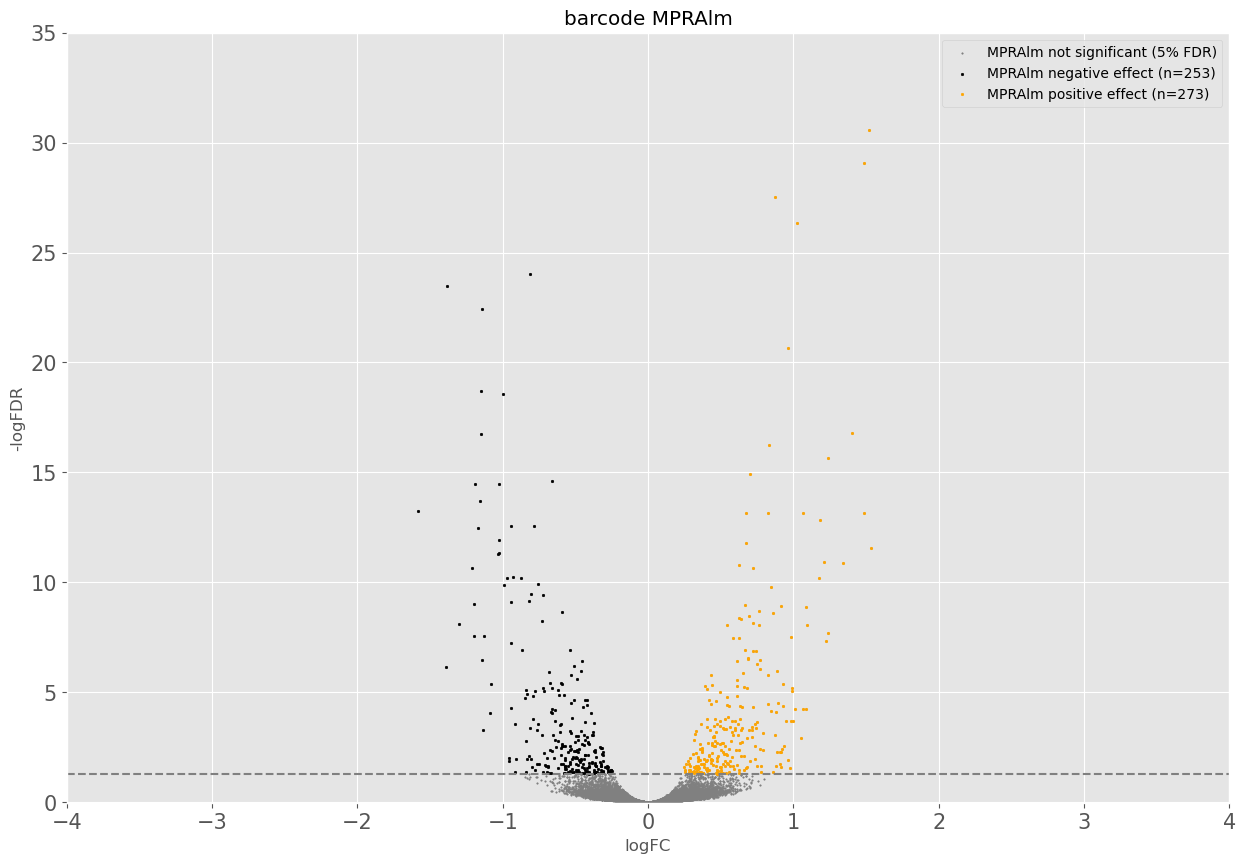

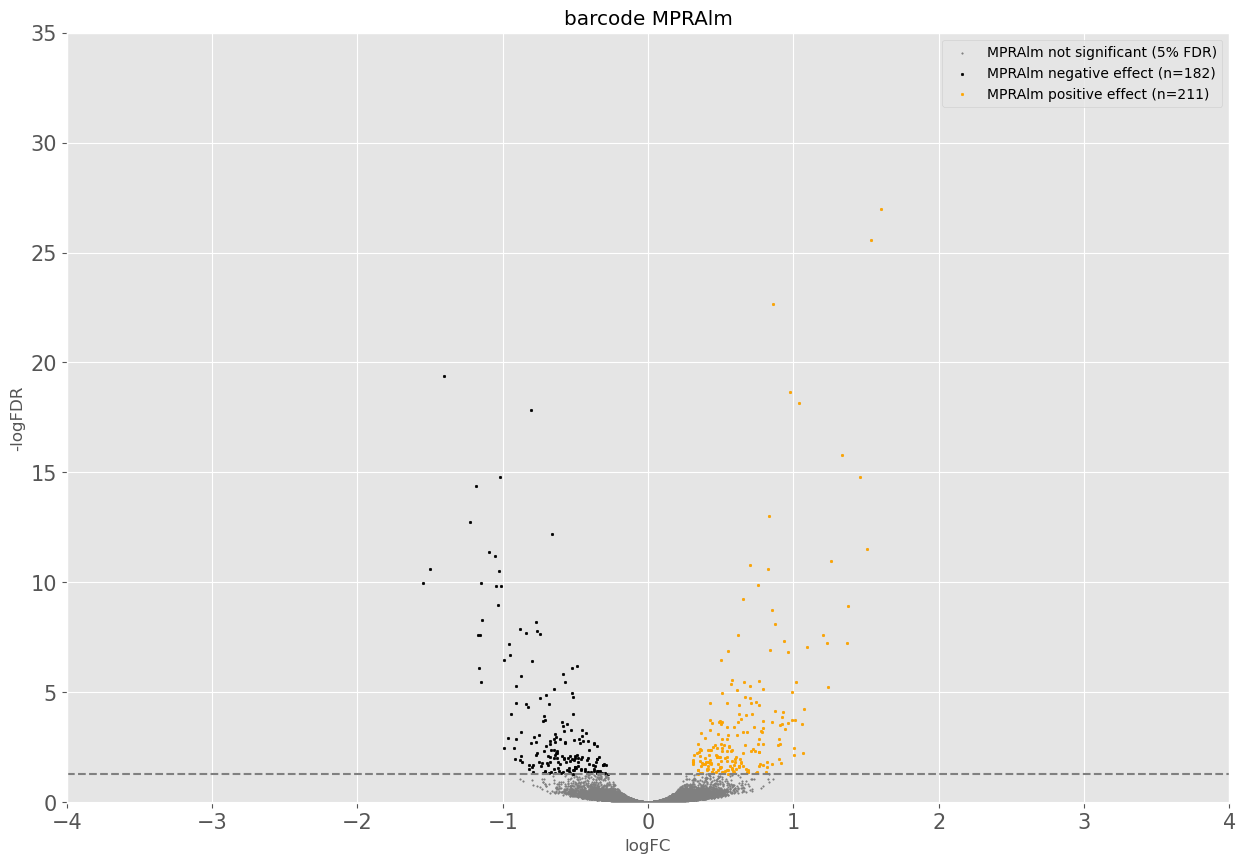

In [19]:
# plot_vulcano(bcMPRAlm_table_no_downsampling, title="barcode MPRAlm No downsampling")
plot_vulcano(bcMPRAlm_table, title="barcode MPRAlm")
# plot_vulcano(MPRAlm_table_no_downsampling, title="aggregated MPRAlm No downsampling")
plot_vulcano(MPRAlm_table, title="barcode MPRAlm")

#### Check the mpralm results

In [8]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10
0,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,49.175946
1,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.973568
2,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.566817
3,0.861337,0.989619,11.188733,2.500592e-27,2.190456e-23,51.127418,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,22.659465
4,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.370104
...,...,...,...,...,...,...,...,...,...
35034,0.000985,-0.148871,0.012271,9.902119e-01,9.972241e-01,-6.730627,cardiac_neuro_cava_random:EYA4|ENSG00000112319...,EYA4|ENSG00000112319.21|EH38E2504357|6-1332486...,0.001207
35035,-0.001101,0.065618,-0.014403,9.885113e-01,9.969637e-01,-6.730694,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542494-A-C,0.001321
35036,0.000991,0.087579,0.012523,9.900111e-01,9.972241e-01,-6.730946,cardiac_neuro_cava_random:ADNP|ENSG00000101126...,ADNP|ENSG00000101126.18|EH38E3439798|20-508954...,0.001207
35037,-0.000613,0.084193,-0.007591,9.939452e-01,9.980755e-01,-6.731004,cardiac_neuro_cava_random:TAB2|ENSG00000055208...,TAB2|ENSG00000055208.20|EH38E3739978|6-1492935...,0.000837


In [7]:
MPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10
0,1.370678,1.860194,17.560799,4.101053e-40,1.436968e-35,79.906151,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,34.842553
1,1.490805,0.707015,14.392835,2.823725e-31,4.947024e-27,59.462699,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,26.305656
2,1.486767,0.997721,13.200114,7.044947e-28,8.228263e-24,51.766157,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,23.084692
3,-1.371246,0.665880,-12.782335,1.097852e-26,9.616906e-23,49.305826,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,negative,22.016965
4,-0.831415,0.761397,-11.708742,1.259688e-23,8.827640e-20,43.029602,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440808...,negative,19.054155
...,...,...,...,...,...,...,...,...,...,...
35034,-0.006053,0.047492,-0.097930,9.221028e-01,9.883900e-01,-7.003960,cardiac_neuro_cava_random:TRAK1|ENSG0000018260...,TRAK1|ENSG00000182606.17|EH38E3507853|3-419861...,neutral,0.005072
35035,-0.012198,0.407752,-0.198848,8.426180e-01,9.771244e-01,-7.004137,cardiac_neuro_cava_random:SOS1|ENSG00000115904...,SOS1|ENSG00000115904.15|EH38E1989571|2-3898168...,neutral,0.010050
35036,0.000315,0.174039,0.005085,9.959485e-01,9.992342e-01,-7.008937,cardiac_neuro_cava_random:VCL|ENSG00000035403....,VCL|ENSG00000035403.18|EH38E2908854|10-7407969...,neutral,0.000333
35037,-0.006273,0.105392,-0.102904,9.181599e-01,9.879948e-01,-7.021133,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ZNF462|ENSG00000148143.13|EH38E3899589|9-10696...,neutral,0.005245


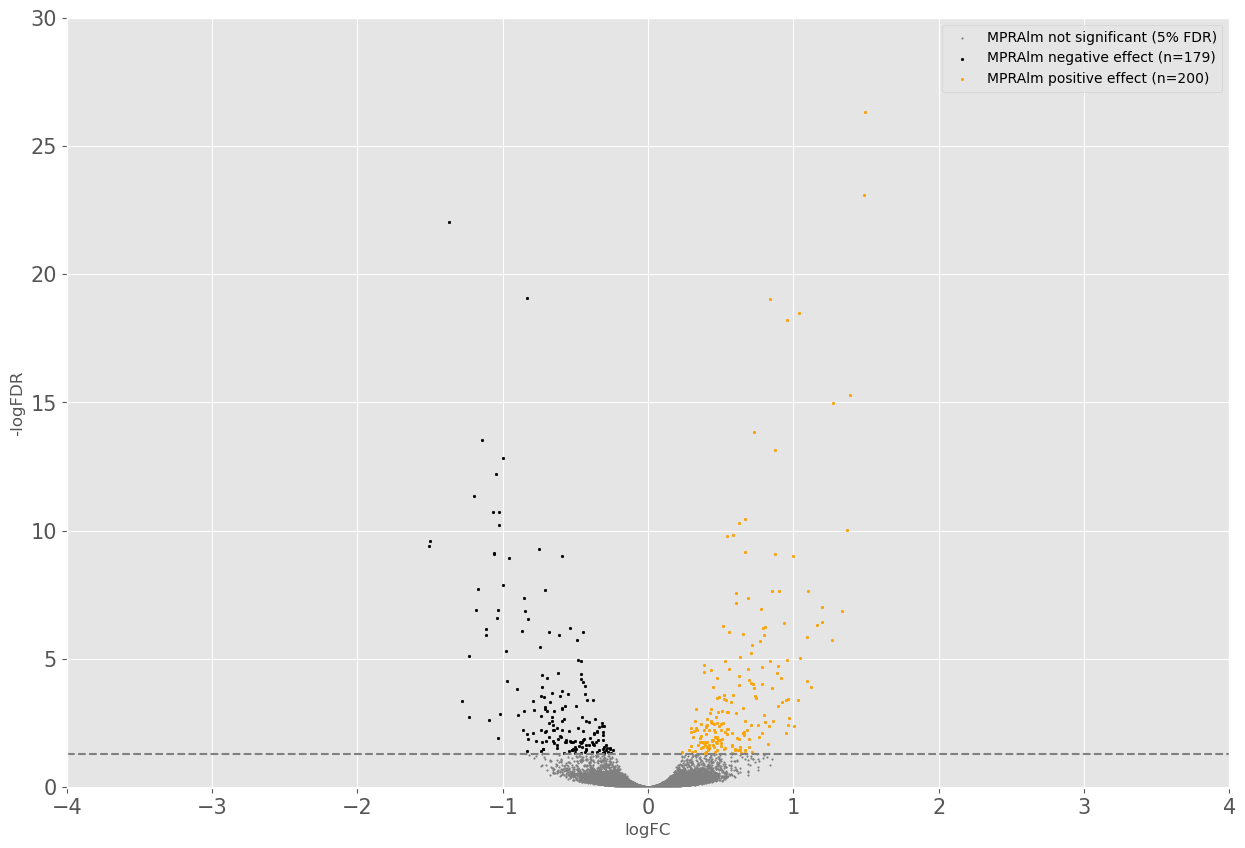

In [5]:
significants_niveau = 0.05
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

significant_MPRAlm_table = MPRAlm_table[MPRAlm_table['adj.P.Val'] < significants_niveau]
up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
ax = plt.gca()
plt.style.use("ggplot")
plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax.set_xlim([-4,4])
ax.set_ylim([-0.025,30])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('mpralm_41k_results.png', transparent=True)

#### Loading functions for analysing the (bc) mpralm results

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# create new column with negative log10 p-value
bcMPRAlm_table["nlog10"] = -np.log10(bcMPRAlm_table["adj.P.Val"])
MPRAlm_table["nlog10"] = -np.log10(MPRAlm_table["adj.P.Val"])

In [25]:
def get_label(header):
    return header.split(":")[0]

def is_tested(header):
    return get_label(header) == 'cardiac_neuro_cava_random'

def is_control(header):
    return not is_tested(header)

def map_color_to_controls(row):
    if is_tested(row):
        return '#377eb8'
    else: return '#ff7f00'
    
def is_common(variant_type):
    return variant_type in ['common', 'rare']
    
# add class to plot for colors
def map_color_precise(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        if abs(log2fc) >= log2fc_threshold:
            return "interesting_high_log2fc"
        else:
            return "interesting_low_pvalue"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        if abs(log2fc) < log2fc_threshold: 
            return "uninteresting_low_log2fc"
        else: 
            return "uninteresting_high_pvalue" 
    return "possibly_interesting"

def map_color(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        return "interesting"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        return "uninteresting" 
    return "possibly_interesting"


def is_positive_control(header):
    """Checks if header is positive control"""
    label = get_label(header)
    if label in positive_control_groups:
        return True
    return False


def is_negative_control(header):
    """Checks if header is negative control"""
    label = get_label(header)
    if label in negative_control_groups:
        return True
    return False

def is_liang_control(header):
    """Checks if header is from Liang control  (08.04: 7 variants)"""
    label = get_label(header)
    if label.lower() == 'GC_Liang'.lower():
        return True
    return False

def is_selvarajan_control(header):
    """Checks if header is from GC_Selvarajan control (08.04: 112 variants)"""
    label = get_label(header)
    if label.lower() == 'GC_Selvarajan'.lower():
        return True
    return False

def is_positive_heart_CAD_control(header):
    """Checks if header is from positive_heart_CAD control (08.04: 43 variants)"""
    label = get_label(header)
    if label.lower() == 'C_positive_heart_CAD'.lower():
        return True
    return False

def is_arial_fib_control(header):
    """Checks if header is from GC_Atrial_fib (08.04: 17 variants) control"""
    label = get_label(header)
    if label.lower() == 'GC_Atrial_fib'.lower():
        return True
    return False

def is_mohlke_control(header):
    """Checks if header is from GC_Mohlke control (08.04: 11 variants)"""
    label = get_label(header)
    if label.lower() == 'GC_Mohlke'.lower():
        return True
    return False

def is_kircher_control(header):
    label = get_label(header)
    if label.lower() == 'GC_Kircher'.lower():
        return True
    return False

def is_mendelian_control(header):
    label = get_label(header)
    if label.lower() == 'GC_Mendelian_variants'.lower():
        return True
    return False

### Correlation between aggregated and bc mpralm results
- use r heatscatter 

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1369478/2836392936.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lims, lims, 'k-', color=color, alpha=0.75, zorder=0)


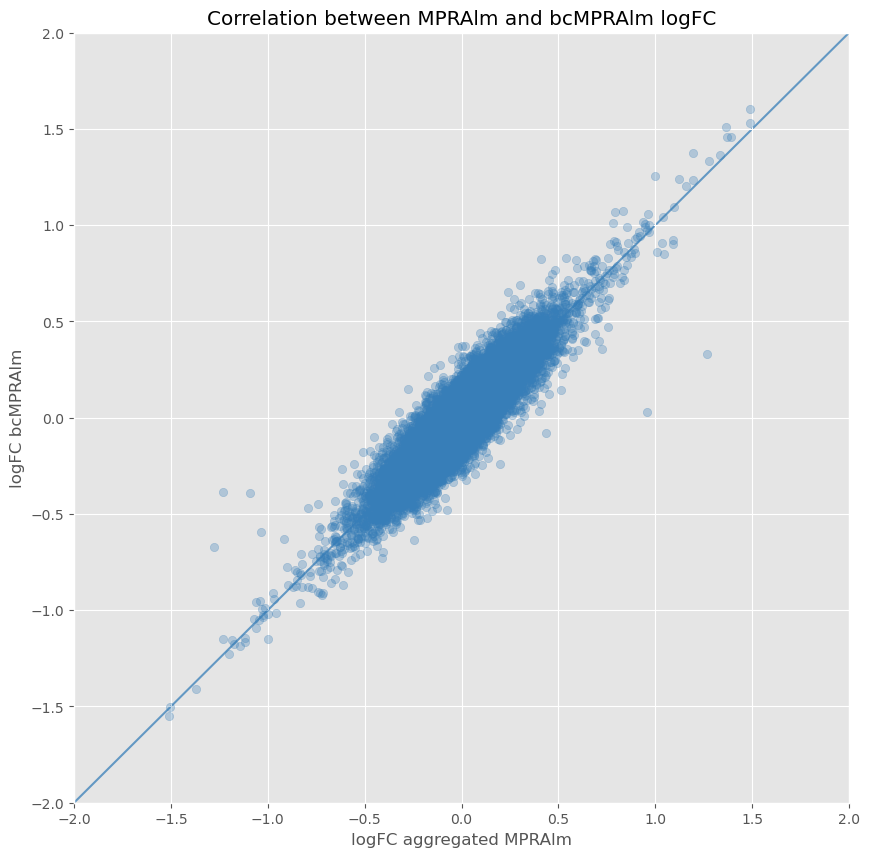

In [16]:
# plot correlation between MPRAlm_table [logFC] and bcMPRAlm_table [logFC]

# merge the two tables
merged_mpralm = pd.merge(MPRAlm_table, bcMPRAlm_table, on="variant_id", suffixes=('_MPRAlm', '_bcMPRAlm'))

# plot log2 correlation between mpralm and bcMPRAlm

fig, ax = plt.subplots(figsize=(10, 10))
# set xlim and ylim
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# set axis names
plt.xlabel("logFC aggregated MPRAlm")
plt.ylabel("logFC bcMPRAlm")
plt.title("Correlation between MPRAlm and bcMPRAlm logFC")

# set color to light blue
color = "#377eb8"

# plot scatter plot
ax.scatter(merged_mpralm["logFC_MPRAlm"], merged_mpralm["logFC_bcMPRAlm"], color=color, alpha=0.3)

# add diagonal line behind the scatter plot
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# plot the diagonal line
ax.plot(lims, lims, 'k-', color=color, alpha=0.75, zorder=0)

# plt.show()
# fig.savefig('../../../80K_analysis/07_quality_control/results/plots/correlation_logFC_MPRAlm_bcMPRAlm.svg', format='svg', dpi=1200)

# plt.savefig('../../../80K_analysis/07_quality_control/results/plots/correlation_logFC_MPRAlm_bcMPRAlm.eps', format='eps')



In [17]:
merged_mpralm.head()

,logFC_MPRAlm,AveExpr_MPRAlm,t_MPRAlm,P.Value_MPRAlm,adj.P.Val_MPRAlm,B_MPRAlm,variant_id,ID_MPRAlm,mpralm_true,nlog10_MPRAlm,logFC_bcMPRAlm,AveExpr_bcMPRAlm,t_bcMPRAlm,P.Value_bcMPRAlm,adj.P.Val_bcMPRAlm,B_bcMPRAlm,ID_bcMPRAlm,nlog10_bcMPRAlm
0,1.370678,1.860194,17.560799,4.101053e-40,1.436968e-35,79.906151,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,34.842553,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,49.175946
1,1.490805,0.707015,14.392835,2.823725e-31,4.947024e-27,59.462699,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,26.305656,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.566817
2,1.486767,0.997721,13.200114,7.044947e-28,8.228263e-24,51.766157,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,23.084692,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.973568
3,-1.371246,0.665880,-12.782335,1.097852e-26,9.616906e-23,49.305826,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,negative,22.016965,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.370104
4,-0.831415,0.761397,-11.708742,1.259688e-23,8.827640e-20,43.029602,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440808...,negative,19.054155,-0.804640,0.762372,-9.963549,3.342047e-22,1.463775e-18,39.579749,TRIO|ENSG00000038382.23|EH38E2358394|5-1440808...,17.834526


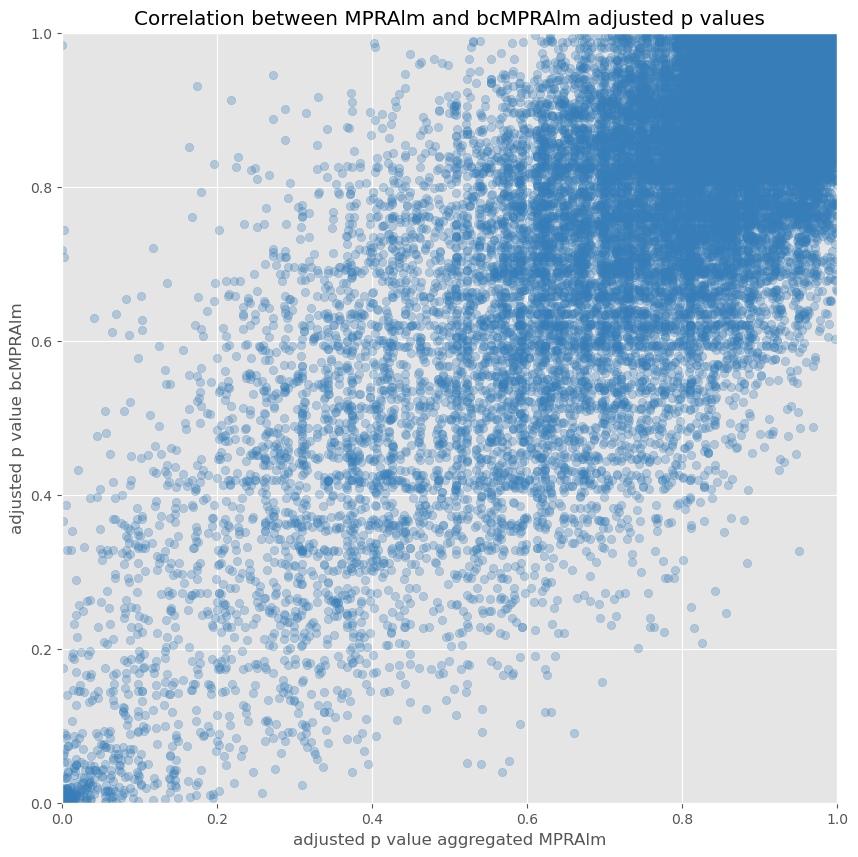

In [22]:
# plot p value correlation

fig, ax = plt.subplots(figsize=(10, 10))
# set xlim and ylim
ax.set_xlim(-0, 1)
ax.set_ylim(-0, 1)

# set axis names
plt.xlabel("adjusted p value aggregated MPRAlm")
plt.ylabel("adjusted p value bcMPRAlm")
plt.title("Correlation between MPRAlm and bcMPRAlm adjusted p values")

# set color to light blue
color = "#377eb8"

# plot scatter plot
ax.scatter(merged_mpralm["adj.P.Val_MPRAlm"], merged_mpralm["adj.P.Val_bcMPRAlm"], color=color, alpha=0.3)

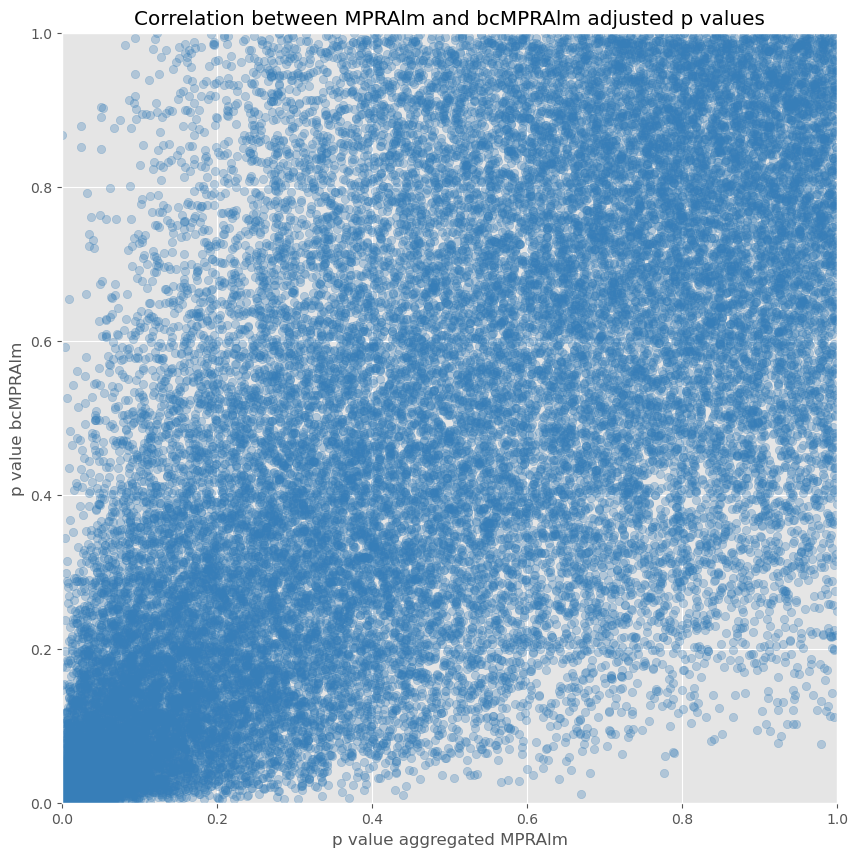

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
# set xlim and ylim
ax.set_xlim(-0, 1)
ax.set_ylim(-0, 1)

# set axis names
plt.xlabel("p value aggregated MPRAlm")
plt.ylabel("p value bcMPRAlm")
plt.title("Correlation between MPRAlm and bcMPRAlm adjusted p values")

# set color to light blue
color = "#377eb8"

# plot scatter plot
ax.scatter(merged_mpralm["P.Value_MPRAlm"], merged_mpralm["P.Value_bcMPRAlm"], color=color, alpha=0.3)

### Investigate aggregated mpralm 
 

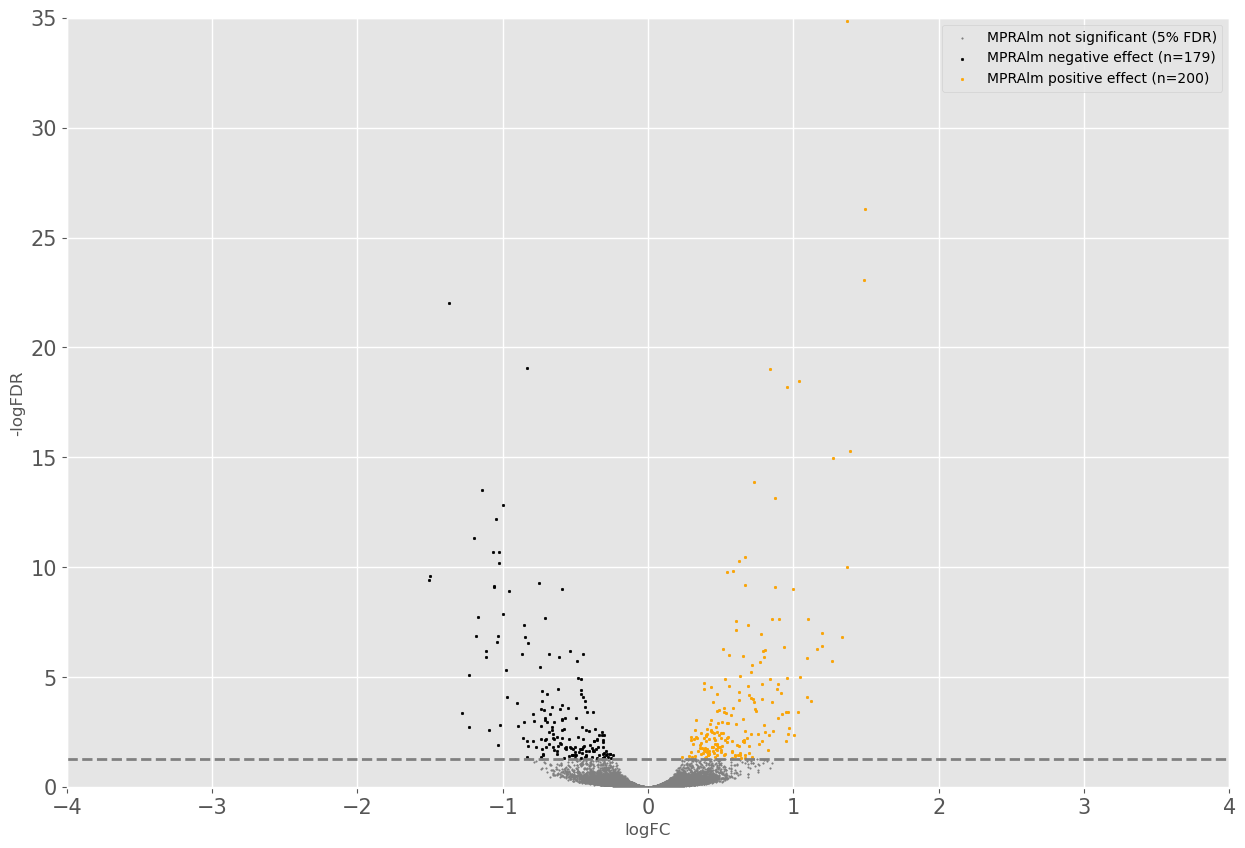

In [63]:
significants_niveau = 0.05
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

significant_MPRAlm_table = MPRAlm_table[MPRAlm_table['adj.P.Val'] < significants_niveau]
mpralm_up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
mpralm_down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=mpralm_down['logFC'],y=mpralm_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm negative effect" + " (n=" + str(mpralm_down.shape[0]) + ")",color="black")
plt.scatter(x=mpralm_up['logFC'],y=mpralm_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm positive effect"+ " (n=" + str(mpralm_up.shape[0]) + ")",color="orange")


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax = plt.gca()
ax.set_xlim([-4,4])
ax.set_ylim([-0.025,35])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('mpralm_34K_results.png', transparent=True)


In [11]:
merged_variant_file = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
merged_variant_df = pd.read_csv(merged_variant_file, sep='\t')
merged_variant_df

# merge with variant information: 
mpralm_merged_variant_table = MPRAlm_table.merge(merged_variant_df, on='ID')

mpralm_controls = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_control)]
mpralm_c_liang = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_liang_control)]
mpralm_c_selvarajan = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_selvarajan_control)]
mpralm_c_positive_heart_CAD = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_positive_heart_CAD_control)]
mpralm_c_arial_fib = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_arial_fib_control)]
mpralm_c_mohlke = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_mohlke_control)]


# significant_variant_table = significant_bcMPRAlm_table.merge(merged_variant_df, on='ID')
mpralm_significant_variant_table = mpralm_merged_variant_table[mpralm_merged_variant_table['adj.P.Val'] < significants_niveau]
mpralm_significant_variant_table[~mpralm_significant_variant_table['gene_type'].isna()].shape[0]
mpralm_significant_variant_table['abs_logFC'] = mpralm_significant_variant_table['logFC'].abs()

merged_up = mpralm_merged_variant_table[mpralm_merged_variant_table['mpralm_true'] == 'positive']
merged_down = mpralm_merged_variant_table[mpralm_merged_variant_table['mpralm_true'] == 'negative']

common_sig_up = merged_up[merged_up['variant_type'].apply(is_common)] 
ultra_rare_sig_up = merged_up[merged_up['variant_type'] == 'ultra-rare']  
singleton_sig_up = merged_up[merged_up['variant_type'] == 'singleton']  
common_sig_down = merged_down[merged_down['variant_type'].apply(is_common)] 
ultra_rare_sig_down = merged_down[merged_down['variant_type'] == 'ultra-rare']  
singleton_sig_down = merged_down[merged_down['variant_type'] == 'singleton']  



/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-187/ipykernel_2524492/2965101702.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpralm_significant_variant_table['abs_logFC'] = mpralm_significant_variant_table['logFC'].abs()


In [12]:
# get size of the variant_type groups: 
variant_type_tables = [common_sig_up, ultra_rare_sig_up, singleton_sig_up, common_sig_down, ultra_rare_sig_down, singleton_sig_down]
variant_type_table_names = ["common_sig_up", "ultra_rare_sig_up", "singleton_sig_up", "common_sig_down", "ultra_rare_sig_down", "singleton_sig_down"]
for i in range(len(variant_type_tables)):
    print(variant_type_table_names[i], variant_type_tables[i].shape[0])
    
# for data with all variant controls (16.04.2024)
# common_sig_up 16
# ultra_rare_sig_up 20
# singleton_sig_up 22
# common_sig_down 14
# ultra_rare_sig_down 15
# singleton_sig_down 18

common_sig_up 16
ultra_rare_sig_up 20
singleton_sig_up 22
common_sig_down 14
ultra_rare_sig_down 15
singleton_sig_down 18


##### compare controls

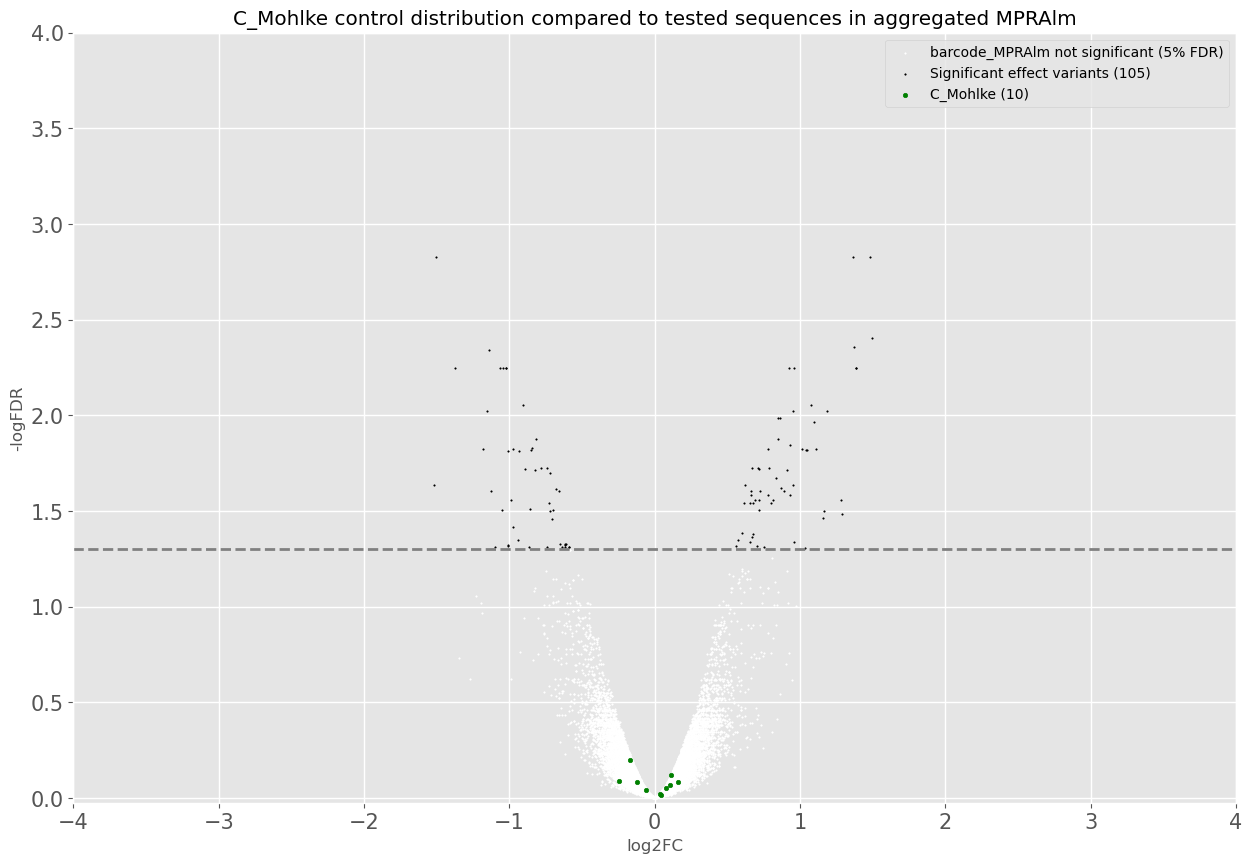

In [15]:
# make vulcano plot with coloring only controls special
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
plt.style.use("Solarize_Light2")
plt.style.use("ggplot")

plt.scatter(x=mpralm_merged_variant_table['logFC'],y=mpralm_merged_variant_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode_MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color='white')
plt.scatter(x=mpralm_significant_variant_table['logFC'],y=mpralm_significant_variant_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"Significant effect variants ({mpralm_significant_variant_table.shape[0]})", color='black')
# scatter for controls
control_dot_size = 10
# plt.scatter(x=mpralm_controls['logFC'],y=mpralm_controls['adj.P.Val'].apply(lambda x:-np.log10(x)),s=2,label="Controls", color='blue')
# plt.scatter(x=mpralm_c_liang['logFC'],y=mpralm_c_liang['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Liang", color='orange')
# plt.scatter(x=mpralm_c_selvarajan['logFC'],y=mpralm_c_selvarajan['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Selvarajan", color='orange')
# plt.scatter(x=mpralm_c_positive_heart_CAD['logFC'],y=mpralm_c_positive_heart_CAD['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_positive_heart_CAD", color='red')
# plt.scatter(x=mpralm_c_arial_fib['logFC'],y=mpralm_c_arial_fib['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_Arial_fib", color='blue')
plt.scatter(x=mpralm_c_mohlke['logFC'],y=mpralm_c_mohlke['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"C_Mohlke ({mpralm_c_mohlke.shape[0]})", color='green')

# modify plot
ax = plt.gca()
ax.set_xlim([-4,4])
ax.set_ylim([-0.025,4])

# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
# plt.title("GC_Liang control distribution compared to tested sequences in aggregated MPRAlm")
plt.title("C_Mohlke control distribution compared to tested sequences in aggregated MPRAlm")
# plt.title("Variant control distribution compared to tested sequences")
plt.xlabel("log2FC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.show()


##### Investigate different types of variants (unfinished)

NameError: name 'common_sig_up' is not defined

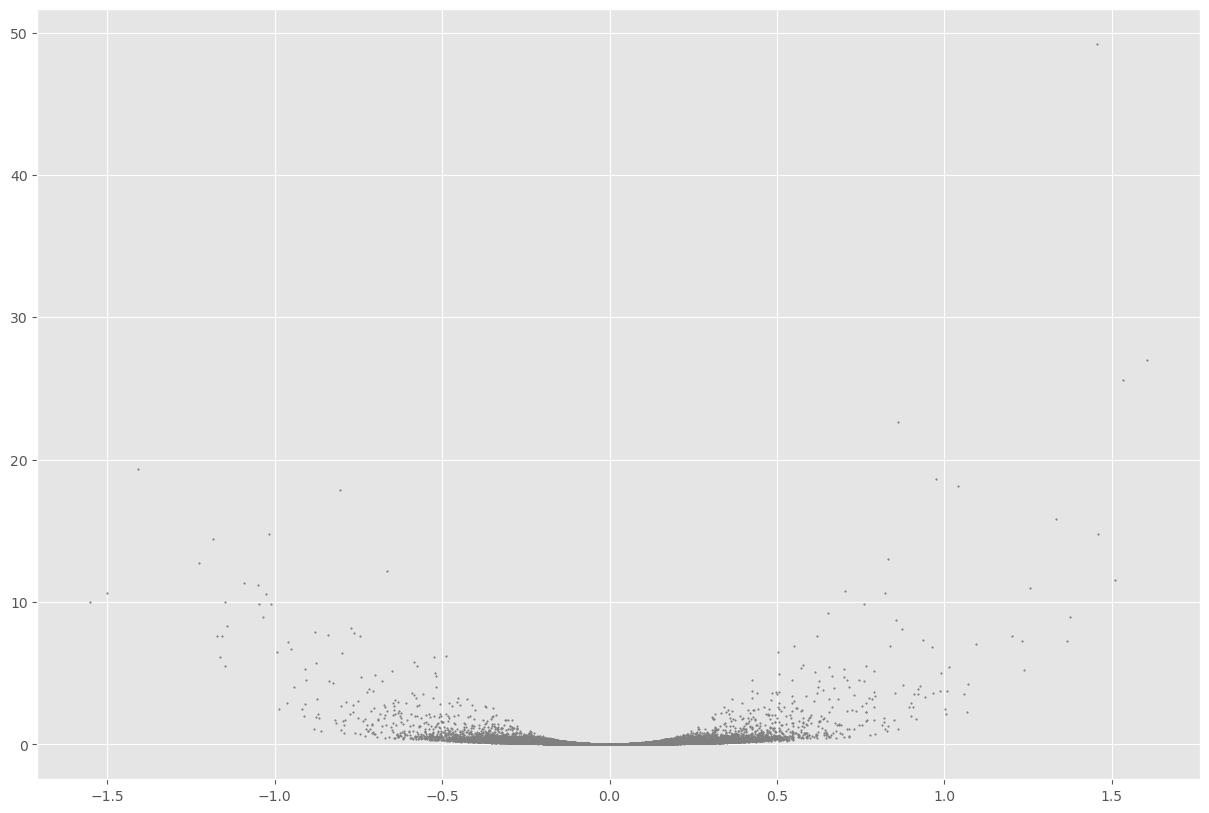

In [24]:
# plot of different types of variants: 
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=common_sig_up['logFC'],y=common_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common up (AF>1%): {common_sig_up.shape[0]}",color="limegreen")
plt.scatter(x=ultra_rare_sig_up['logFC'],y=ultra_rare_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare up (AF<=1%): {ultra_rare_sig_up.shape[0]}",color="violet")
plt.scatter(x=singleton_sig_up['logFC'],y=singleton_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton up: {singleton_sig_up.shape[0]}",color="deepskyblue")
plt.scatter(x=common_sig_down['logFC'],y=common_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common down (AF>1%): {common_sig_down.shape[0]}",color="darkgreen")
plt.scatter(x=ultra_rare_sig_down['logFC'],y=ultra_rare_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare down (AF<=1%): {ultra_rare_sig_down.shape[0]}",color="purple")
plt.scatter(x=singleton_sig_down['logFC'],y=singleton_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton down: {singleton_sig_down.shape[0]}",color="red")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax = plt.gca()
ax.set_xlim([-4,4])
ax.set_ylim([-0.025,4])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('bc_mpralm_41k_results.png', transparent=True)

In [18]:
log2fc_bcMPRAlm = bcMPRAlm_table[['variant_id', 'adj.P.Val', 'logFC']]

In [19]:
# correlation between log2fc values of barcode mpralm and aggregated mpralm

# merge log2fc of barcode mpralm to the mpralm 
MPRAlm_table.merge(log2fc_bcMPRAlm, on='variant_id', how='left')

,logFC_x,AveExpr,t,P.Value,adj.P.Val_x,B,variant_id,ID,mpralm_true,nlog10,adj.P.Val_y,logFC_y
0,-1.504265,0.183954,-16.231642,6.139532e-08,0.001480,7.144563,cardiac_neuro_cava_random:IRX3|ENSG00000177508...,IRX3|ENSG00000177508.12|EH38E3181492|16-543166...,negative,2.829689,1.044405e-10,-1.552628
1,1.366217,1.856935,15.095484,1.150286e-07,0.001480,6.815929,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,2.829689,6.441446e-50,1.456861
2,1.481276,0.704644,14.909268,1.280312e-07,0.001480,6.718709,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,2.829689,2.805444e-26,1.533345
3,1.493970,0.994326,12.865364,4.533388e-07,0.003931,5.994325,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,2.405520,1.048678e-27,1.606482
4,1.369303,1.202492,12.361659,6.367299e-07,0.004417,5.760239,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,GATA4|ENSG00000136574.19|EH38E2610941|8-116424...,positive,2.354898,3.196692e-12,1.508360
...,...,...,...,...,...,...,...,...,...,...,...,...
34678,0.001521,-0.017681,0.015629,9.878735e-01,0.999058,-6.274916,cardiac_neuro_cava_random:RAF1|ENSG00000132155...,RAF1|ENSG00000132155.14|EH38E2179355|3-1265878...,neutral,0.000409,9.890075e-01,-0.008968
34679,-0.002798,-0.584892,-0.017991,9.860415e-01,0.998459,-6.275805,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,CASZ1|ENSG00000130940.15|EH38E2785609|1-106435...,neutral,0.000670,9.056479e-01,-0.166315
34680,0.000252,0.279646,0.001836,9.985754e-01,0.999891,-6.276481,cardiac_neuro_cava_random:ECE1|ENSG00000117298...,ECE1|ENSG00000117298.16|EH38E1326097|1-2135073...,neutral,0.000048,9.460602e-01,-0.089561
34681,-0.001265,0.061353,-0.014976,9.883804e-01,0.999058,-6.277634,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ZNF462|ENSG00000148143.13|EH38E2715195|9-10704...,neutral,0.000409,9.416030e-01,-0.056102


In [40]:
bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < 0.05] # 386 with 10 barcodes; 393 with 10 barcodes with downsampling
# MPRAlm_table[MPRAlm_table['adj.P.Val'] < 0.05] # 105 with 10 barcodes; 379  with 10 barcodes with downsampling

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,label
0,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,49.175946,positive,cardiac_neuro_cava_random
1,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.973568,positive,cardiac_neuro_cava_random
2,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.566817,positive,cardiac_neuro_cava_random
3,0.861337,0.989619,11.188733,2.500592e-27,2.190456e-23,51.127418,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,22.659465,positive,cardiac_neuro_cava_random
4,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.370104,negative,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...
396,-0.314957,0.512269,-3.494153,5.051418e-04,4.657806e-02,-0.611039,cardiac_neuro_cava_random:LRRC4C|ENSG000001489...,LRRC4C|ENSG00000148948.8|EH38E1534651|11-41113...,1.331819,negative,cardiac_neuro_cava_random
400,0.346784,-0.160274,3.469248,5.556839e-04,4.966992e-02,-0.659838,cardiac_neuro_cava_random:MED13L|ENSG000001230...,MED13L|ENSG00000123066.9|EH38E3043648|12-11616...,1.303907,positive,cardiac_neuro_cava_random
403,0.358435,-0.316231,3.470095,5.509918e-04,4.963034e-02,-0.670543,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,IRF4|ENSG00000137265.16|EH38E2438412|6-405889-C-T,1.304253,positive,cardiac_neuro_cava_random
412,-0.297921,-0.059217,-3.477754,5.314980e-04,4.849781e-02,-0.758377,cardiac_neuro_cava_random:CUL3|ENSG00000036257...,CUL3|ENSG00000036257.14|EH38E2079109|2-2245462...,1.314278,negative,cardiac_neuro_cava_random


In [30]:
# add label to bcMPRAlm_table
bcMPRAlm_table['label'] = bcMPRAlm_table['variant_id'].apply(get_label)
MPRAlm_table['label'] = MPRAlm_table['variant_id'].apply(get_label)

In [31]:
merged_variant_file = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
merged_variant_df = pd.read_csv(merged_variant_file, sep='\t')
merged_variant_df
# significant_variant_table = significant_bcMPRAlm_table.merge(merged_variant_df, on='ID')

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type
0,chr1,3030162,PRDM16|ENSG00000142611.17|EH38E1312284|1-30301...,T,A,1,PASS,AF=0.247769;AC=37649,cardiac,common
1,chr1,3030855,PRDM16|ENSG00000142611.17|EH38E2779521|1-30308...,G,A,1,PASS,AF=0.0757297;AC=11520,cardiac,common
2,chr1,3033425,PRDM16|ENSG00000142611.17|EH38E1312290|1-30334...,A,C,1,AS_VQSR,AF=0.0564555;AC=4921,cardiac,common
3,chr1,3033673,PRDM16|ENSG00000142611.17|EH38E2779527|1-30336...,G,A,1,PASS,AF=0.170986;AC=25994,cardiac,common
4,chr1,3033770,PRDM16|ENSG00000142611.17|EH38E2779527|1-30337...,G,A,1,PASS,AF=0.171221;AC=26042,cardiac,common
...,...,...,...,...,...,...,...,...,...,...
71405,chr6,26284345,H1-3|ENSG00000124575.7|EH38E3697740|6-26284345...,G,A,1,PASS,AF=6.57903e-06;AC=1,random,singleton
71406,chr2,210478202,CPS1|ENSG00000021826.18|EH38E3397495|2-2104782...,C,T,1,PASS,AF=6.5697e-06;AC=1,random,singleton
71407,chr2,210477975,CPS1|ENSG00000021826.18|EH38E3397495|2-2104779...,G,C,1,PASS,AF=6.57315e-06;AC=1,random,singleton
71408,chr2,210478142,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,T,A,1,PASS,AF=6.56858e-06;AC=1,random,singleton


In [23]:
bcMPRAlm_table
MPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,label
0,-1.504265,0.183954,-16.231642,6.139532e-08,0.001480,7.144563,cardiac_neuro_cava_random:IRX3|ENSG00000177508...,IRX3|ENSG00000177508.12|EH38E3181492|16-543166...,negative,2.829689,cardiac_neuro_cava_random
1,1.366217,1.856935,15.095484,1.150286e-07,0.001480,6.815929,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,2.829689,cardiac_neuro_cava_random
2,1.481276,0.704644,14.909268,1.280312e-07,0.001480,6.718709,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,2.829689,cardiac_neuro_cava_random
3,1.493970,0.994326,12.865364,4.533388e-07,0.003931,5.994325,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,2.405520,cardiac_neuro_cava_random
4,1.369303,1.202492,12.361659,6.367299e-07,0.004417,5.760239,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,GATA4|ENSG00000136574.19|EH38E2610941|8-116424...,positive,2.354898,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...
34678,0.001521,-0.017681,0.015629,9.878735e-01,0.999058,-6.274916,cardiac_neuro_cava_random:RAF1|ENSG00000132155...,RAF1|ENSG00000132155.14|EH38E2179355|3-1265878...,neutral,0.000409,cardiac_neuro_cava_random
34679,-0.002798,-0.584892,-0.017991,9.860415e-01,0.998459,-6.275805,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,CASZ1|ENSG00000130940.15|EH38E2785609|1-106435...,neutral,0.000670,cardiac_neuro_cava_random
34680,0.000252,0.279646,0.001836,9.985754e-01,0.999891,-6.276481,cardiac_neuro_cava_random:ECE1|ENSG00000117298...,ECE1|ENSG00000117298.16|EH38E1326097|1-2135073...,neutral,0.000048,cardiac_neuro_cava_random
34681,-0.001265,0.061353,-0.014976,9.883804e-01,0.999058,-6.277634,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ZNF462|ENSG00000148143.13|EH38E2715195|9-10704...,neutral,0.000409,cardiac_neuro_cava_random


In [32]:
significants_niveau = 0.05
bcMPRAlm_table['mpralm_true'] = np.where((bcMPRAlm_table['logFC'] > 0) & (bcMPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
bcMPRAlm_table['mpralm_true'] = np.where((bcMPRAlm_table['logFC'] < 0) & (bcMPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', bcMPRAlm_table['mpralm_true'])

# merge with variant information: 
bc_mpralm_merged_variant_table = bcMPRAlm_table.merge(merged_variant_df, on='ID')

significant_bcMPRAlm_table = bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < significants_niveau]
up = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] == 'positive']
down = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] == 'negative']
controls = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_control)]
c_liang = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_liang_control)]
c_selvarajan = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_selvarajan_control)]
c_positive_heart_CAD = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_positive_heart_CAD_control)]
c_arial_fib = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_arial_fib_control)]
c_mohlke = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_mohlke_control)]
c_kircher = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_kircher_control)]
c_mendelian = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_mendelian_control)]

In [33]:
print("All controls in bc MPRAlm: ", controls.shape[0])
controls['label'].value_counts()
# label
# GC_Selvarajan            150
# GC_Kircher               140
# GC_Mendelian_variants     41
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Mohlke                 13
# GC_Liang                   5

# solved mendelian variants problem
# label
# GC_Selvarajan            150
# GC_Mendelian_variants    147
# GC_Kircher               140
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Mohlke                 13
# GC_Liang                   5

All controls in bc MPRAlm:  514


label
GC_Selvarajan            150
GC_Mendelian_variants    147
GC_Kircher               140
C_positive_heart_CAD      39
GC_Atrial_fib             20
GC_Mohlke                 13
GC_Liang                   5
Name: count, dtype: int64

In [34]:
# investigate variant_ids of c_liang # only 5 if 10 barcodes
c_liang

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,label
10630,0.176982,0.171634,0.773852,0.439582,0.889341,-5.482092,GC_Liang:rs2125358,rs2125358,0.050932,neutral,GC_Liang
13728,-0.149876,-0.467654,-0.964378,0.335399,0.846808,-5.663307,GC_Liang:rs10502466,rs10502466,0.072215,neutral,GC_Liang
16409,0.131272,-0.266985,0.891231,0.373281,0.862798,-5.775457,GC_Liang:rs10939614,rs10939614,0.064091,neutral,GC_Liang
17679,-0.119427,-0.794555,-0.720998,0.471323,0.897202,-5.826942,GC_Liang:rs17603855,rs17603855,0.047110,neutral,GC_Liang
29899,-0.060590,0.107805,-0.613839,0.539529,0.916532,-6.318448,GC_Liang:rs1036014,rs1036014,0.037852,neutral,GC_Liang


In [35]:
controls.groupby('label').size()
# 10 barcodes
# label
# C_positive_heart_CAD    39
# GC_Atrial_fib           14
# GC_Liang                 5
# GC_Mohlke               10
# GC_Selvarajan           90

# 10 barcodes with downsampling
# label
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Kircher               140
# GC_Liang                   5
# GC_Mendelian_variants    147
# GC_Mohlke                 13
# GC_Selvarajan            150

label
C_positive_heart_CAD      39
GC_Atrial_fib             20
GC_Kircher               140
GC_Liang                   5
GC_Mendelian_variants    147
GC_Mohlke                 13
GC_Selvarajan            150
dtype: int64

In [36]:
not_neutral = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] != 'neutral']
not_neutral_control = not_neutral[not_neutral['variant_id'].apply(is_control)]

In [37]:
not_neutral_control # C_positive_heart_CAD; GC_Selvarajan

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,label
38,-0.746806,0.614943,-6.798786,2.584035e-11,2.321590e-08,15.268587,GC_Selvarajan:rs1680636fwd_tile1-1,rs1680636fwd_tile1-1,7.634215,negative,GC_Selvarajan
301,0.626052,0.161550,3.740001,2.084291e-04,2.340752e-02,0.480206,C_positive_heart_CAD:rs10774625,rs10774625,1.630645,positive,C_positive_heart_CAD
333,0.545908,-0.021540,3.623292,3.251797e-04,3.342316e-02,0.042468,GC_Mendelian_variants:ALT_chr7:156791257G*A|SH...,ALT_chr7,1.475952,positive,GC_Mendelian_variants


In [38]:
not_neutral

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,label
0,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,49.175946,positive,cardiac_neuro_cava_random
1,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.973568,positive,cardiac_neuro_cava_random
2,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.566817,positive,cardiac_neuro_cava_random
3,0.861337,0.989619,11.188733,2.500592e-27,2.190456e-23,51.127418,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,22.659465,positive,cardiac_neuro_cava_random
4,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.370104,negative,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...
396,-0.314957,0.512269,-3.494153,5.051418e-04,4.657806e-02,-0.611039,cardiac_neuro_cava_random:LRRC4C|ENSG000001489...,LRRC4C|ENSG00000148948.8|EH38E1534651|11-41113...,1.331819,negative,cardiac_neuro_cava_random
400,0.346784,-0.160274,3.469248,5.556839e-04,4.966992e-02,-0.659838,cardiac_neuro_cava_random:MED13L|ENSG000001230...,MED13L|ENSG00000123066.9|EH38E3043648|12-11616...,1.303907,positive,cardiac_neuro_cava_random
403,0.358435,-0.316231,3.470095,5.509918e-04,4.963034e-02,-0.670543,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,IRF4|ENSG00000137265.16|EH38E2438412|6-405889-C-T,1.304253,positive,cardiac_neuro_cava_random
412,-0.297921,-0.059217,-3.477754,5.314980e-04,4.849781e-02,-0.758377,cardiac_neuro_cava_random:CUL3|ENSG00000036257...,CUL3|ENSG00000036257.14|EH38E2079109|2-2245462...,1.314278,negative,cardiac_neuro_cava_random


In [29]:
not_neutral_control # only one negative control variant is negative (threshold = 0.05)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,label,mpralm_true
40,-0.746576,0.614591,-6.794636,2.650321e-11,2.258138e-08,15.243590,GC_Selvarajan:rs1680636fwd_tile1-1,rs1680636fwd_tile1-1,7.646249,GC_Selvarajan,negative
121,0.464079,-0.022004,4.911565,1.110094e-06,3.178599e-04,5.074145,GC_Mendelian_variants:chr7:156791274T>TTAAGGAA...,chr7,3.497764,GC_Mendelian_variants,positive
301,0.625242,0.161320,3.733666,2.135212e-04,2.421733e-02,0.459378,C_positive_heart_CAD:rs10774625,rs10774625,1.615874,C_positive_heart_CAD,positive


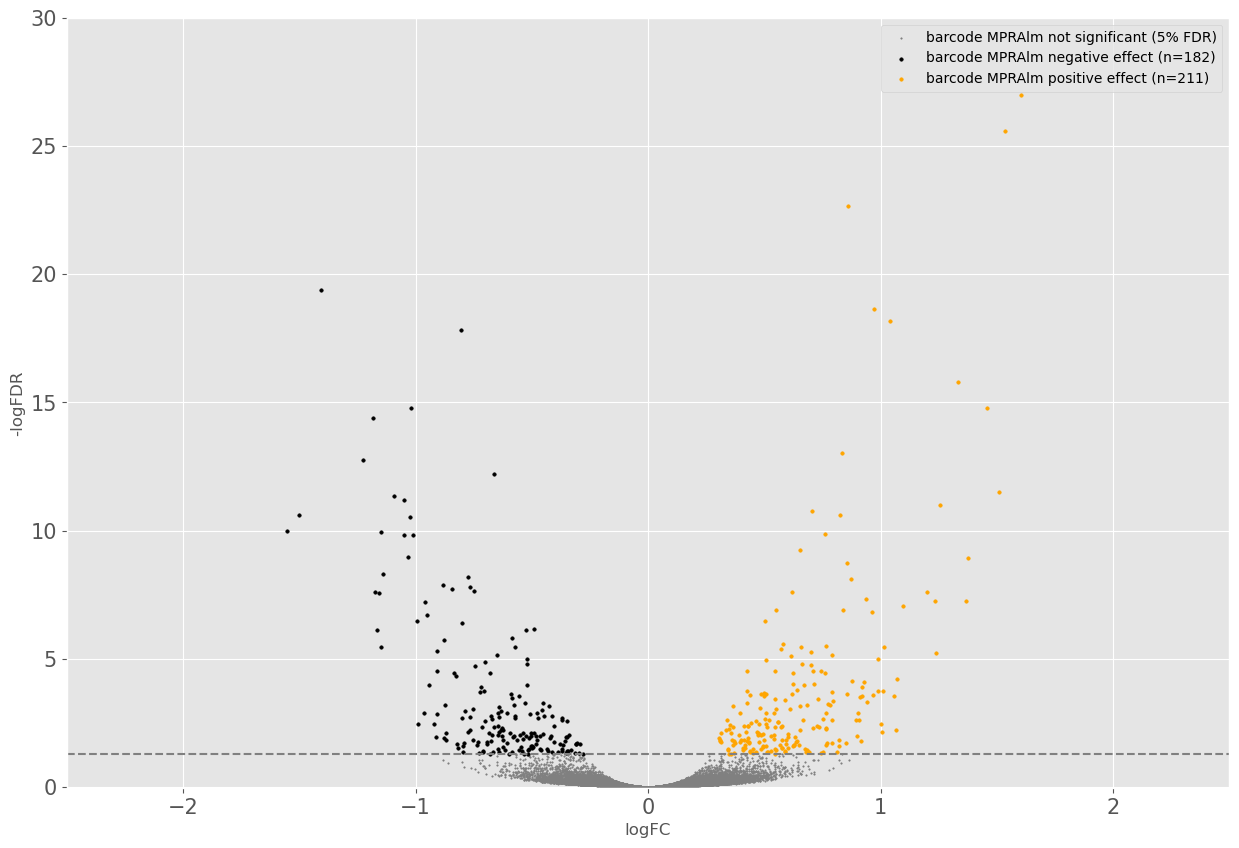

In [41]:
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=6,label="barcode MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=6,label="barcode MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax = plt.gca()
ax.set_xlim([-2.5,2.5])
ax.set_ylim([-0.025,30])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

# plt.savefig('mpralm_41k_results.png', transparent=True)

In [42]:
def is_common(variant_type):
    return variant_type in ['common', 'rare']

In [43]:
merged_variant_file = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
merged_variant_df = pd.read_csv(merged_variant_file, sep='\t')
merged_variant_df
# significant_variant_table = significant_bcMPRAlm_table.merge(merged_variant_df, on='ID')
significant_variant_table = bc_mpralm_merged_variant_table[bc_mpralm_merged_variant_table['adj.P.Val'] < significants_niveau]
significant_variant_table[~significant_variant_table['gene_type'].isna()].shape[0]
significant_variant_table['abs_logFC'] = significant_variant_table['logFC'].abs()

merged_up = bc_mpralm_merged_variant_table[bc_mpralm_merged_variant_table['mpralm_true'] == 'positive']
merged_down = bc_mpralm_merged_variant_table[bc_mpralm_merged_variant_table['mpralm_true'] == 'negative']

common_sig_up = merged_up[merged_up['variant_type'].apply(is_common)] # 159
ultra_rare_sig_up = merged_up[merged_up['variant_type'] == 'ultra-rare'] # 112 
singleton_sig_up = merged_up[merged_up['variant_type'] == 'singleton'] # 130 
common_sig_down = merged_down[merged_down['variant_type'].apply(is_common)] # 159
ultra_rare_sig_down = merged_down[merged_down['variant_type'] == 'ultra-rare'] # 112 
singleton_sig_down = merged_down[merged_down['variant_type'] == 'singleton'] # 130 

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-56/ipykernel_1369478/3281310800.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_variant_table['abs_logFC'] = significant_variant_table['logFC'].abs()


In [44]:
# get size of the variant_type groups: 
variant_type_tables = [common_sig_up, ultra_rare_sig_up, singleton_sig_up, common_sig_down, ultra_rare_sig_down, singleton_sig_down]
variant_type_table_names = ["common_sig_up", "ultra_rare_sig_up", "singleton_sig_up", "common_sig_down", "ultra_rare_sig_down", "singleton_sig_down"]
for i in range(len(variant_type_tables)):
    print(variant_type_table_names[i], variant_type_tables[i].shape[0])

# bc MPRAlm with 10 barcodes and all variant controls
# common_sig_up 75
# ultra_rare_sig_up 63
# singleton_sig_up 75
# common_sig_down 80
# ultra_rare_sig_down 51
# singleton_sig_down 53

common_sig_up 76
ultra_rare_sig_up 64
singleton_sig_up 76
common_sig_down 80
ultra_rare_sig_down 51
singleton_sig_down 53


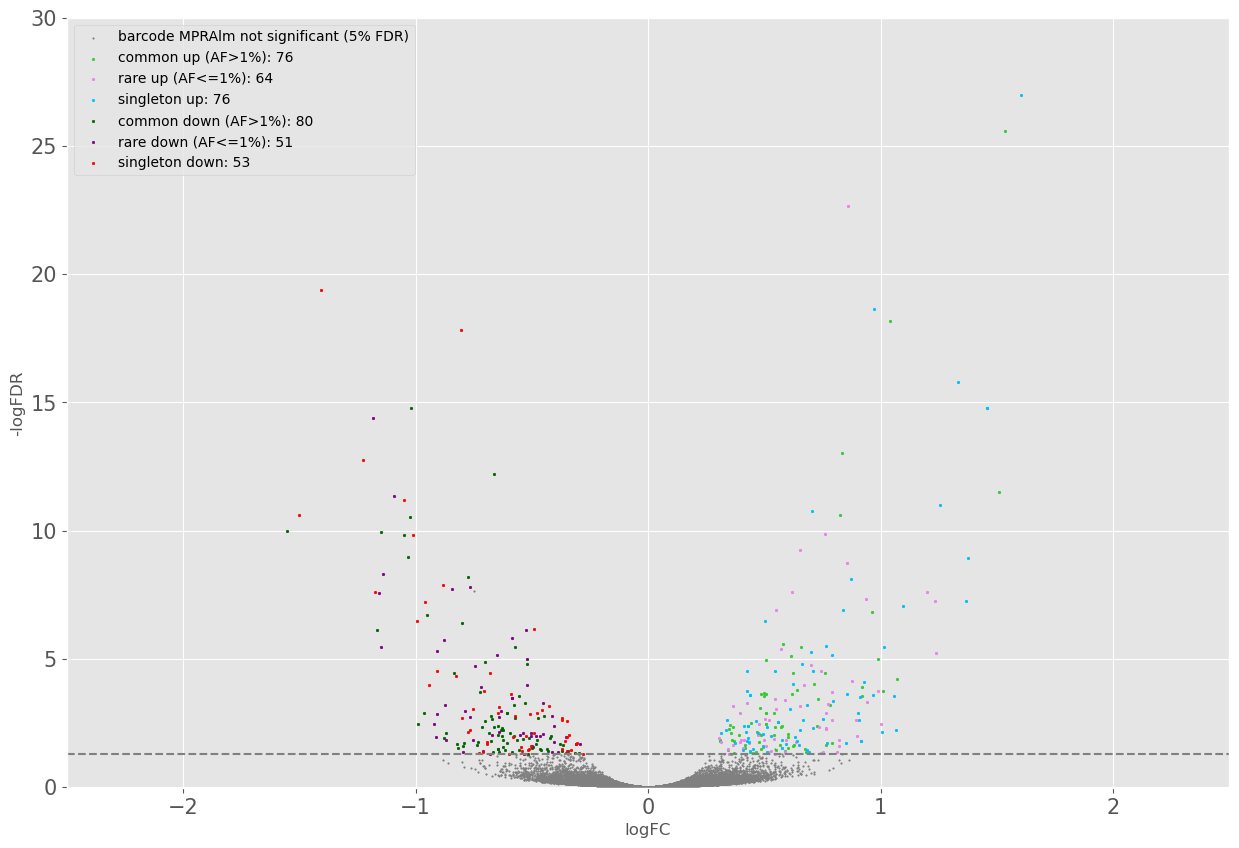

In [47]:
# plot of different types of variants: 
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=common_sig_up['logFC'],y=common_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common up (AF>1%): {common_sig_up.shape[0]}",color="limegreen")
plt.scatter(x=ultra_rare_sig_up['logFC'],y=ultra_rare_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare up (AF<=1%): {ultra_rare_sig_up.shape[0]}",color="violet")
plt.scatter(x=singleton_sig_up['logFC'],y=singleton_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton up: {singleton_sig_up.shape[0]}",color="deepskyblue")
plt.scatter(x=common_sig_down['logFC'],y=common_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common down (AF>1%): {common_sig_down.shape[0]}",color="darkgreen")
plt.scatter(x=ultra_rare_sig_down['logFC'],y=ultra_rare_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare down (AF<=1%): {ultra_rare_sig_down.shape[0]}",color="purple")
plt.scatter(x=singleton_sig_down['logFC'],y=singleton_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton down: {singleton_sig_down.shape[0]}",color="red")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
# plt.xlim(-4,4)
# plt.ylim(-0.025,4)
plt.xlim(-2.5,2.5)
plt.ylim(-0.025,30)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('bc_mpralm_41k_results.png', transparent=True)

In [48]:
significant_variant_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,...,CHROM,POS,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,abs_logFC
0,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,49.175946,positive,...,chr5,14408059,A,G,1,PASS,AF=6.57117e-06;AC=1,neuro,singleton,1.457088
1,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.973568,positive,...,chr2,219267001,T,C,1,PASS,AF=6.57566e-06;AC=1,random,singleton,1.606057
2,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.566817,positive,...,chr5,14259916,C,T,1,PASS,AF=0.0168281;AC=2558,neuro,rare,1.533407
3,0.861337,0.989619,11.188733,2.500592e-27,2.190456e-23,51.127418,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,22.659465,positive,...,chr3,142578095,C,G,1,PASS,AF=4.60054e-05;AC=7,cava,ultra-rare,0.861337
4,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.370104,negative,...,chr22,42115774,T,C,1,PASS,AF=6.57281e-06;AC=1,cava,singleton,1.407245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,0.346784,-0.160274,3.469248,5.556839e-04,4.966992e-02,-0.659838,cardiac_neuro_cava_random:MED13L|ENSG000001230...,MED13L|ENSG00000123066.9|EH38E3043648|12-11616...,1.303907,positive,...,chr12,116160435,C,T,1,PASS,AF=2.6295e-05;AC=4,cardiac,ultra-rare,0.346784
407,0.346784,-0.160274,3.469248,5.556839e-04,4.966992e-02,-0.659838,cardiac_neuro_cava_random:MED13L|ENSG000001230...,MED13L|ENSG00000123066.9|EH38E3043648|12-11616...,1.303907,positive,...,chr12,116160435,C,T,1,PASS,AF=2.6295e-05;AC=4,neuro,ultra-rare,0.346784
410,0.358435,-0.316231,3.470095,5.509918e-04,4.963034e-02,-0.670543,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,IRF4|ENSG00000137265.16|EH38E2438412|6-405889-C-T,1.304253,positive,...,chr6,405889,C,T,1,PASS,AF=0.0192788;AC=2934,cava,rare,0.358435
419,-0.297921,-0.059217,-3.477754,5.314980e-04,4.849781e-02,-0.758377,cardiac_neuro_cava_random:CUL3|ENSG00000036257...,CUL3|ENSG00000036257.14|EH38E2079109|2-2245462...,1.314278,negative,...,chr2,224546256,A,T,1,PASS,AF=0.746252;AC=113387,neuro,common,0.297921


In [49]:
neuro = significant_variant_table[significant_variant_table['gene_type'] == 'neuro'] # 159
cardiac = significant_variant_table[significant_variant_table['gene_type'] == 'cardiac'] # 159
cava = significant_variant_table[significant_variant_table['gene_type'] == 'cava'] # 159
random = significant_variant_table[significant_variant_table['gene_type'] == 'random'] # 159
# neuro = merged_up[merged_up['gene_type'] == 'neuro'] # 159
# cardiac = merged_up[merged_up['gene_type'] == 'cardiac'] # 159
# cava = merged_up[merged_up['gene_type'] == 'cava'] # 159
# random = merged_up[merged_up['gene_type'] == 'random'] # 159
# ultra_rare_sig_up = merged_up[merged_up['variant_type'] == 'ultra-rare'] # 112 
# singleton_sig_up = merged_up[merged_up['variant_type'] == 'singleton'] # 130 
# common_sig_down = merged_down[merged_down['variant_type'].apply(is_common)] # 159
# ultra_rare_sig_down = merged_down[merged_down['variant_type'] == 'ultra-rare'] # 112 
# singleton_sig_down = merged_down[merged_down['variant_type'] == 'singleton'] # 130 

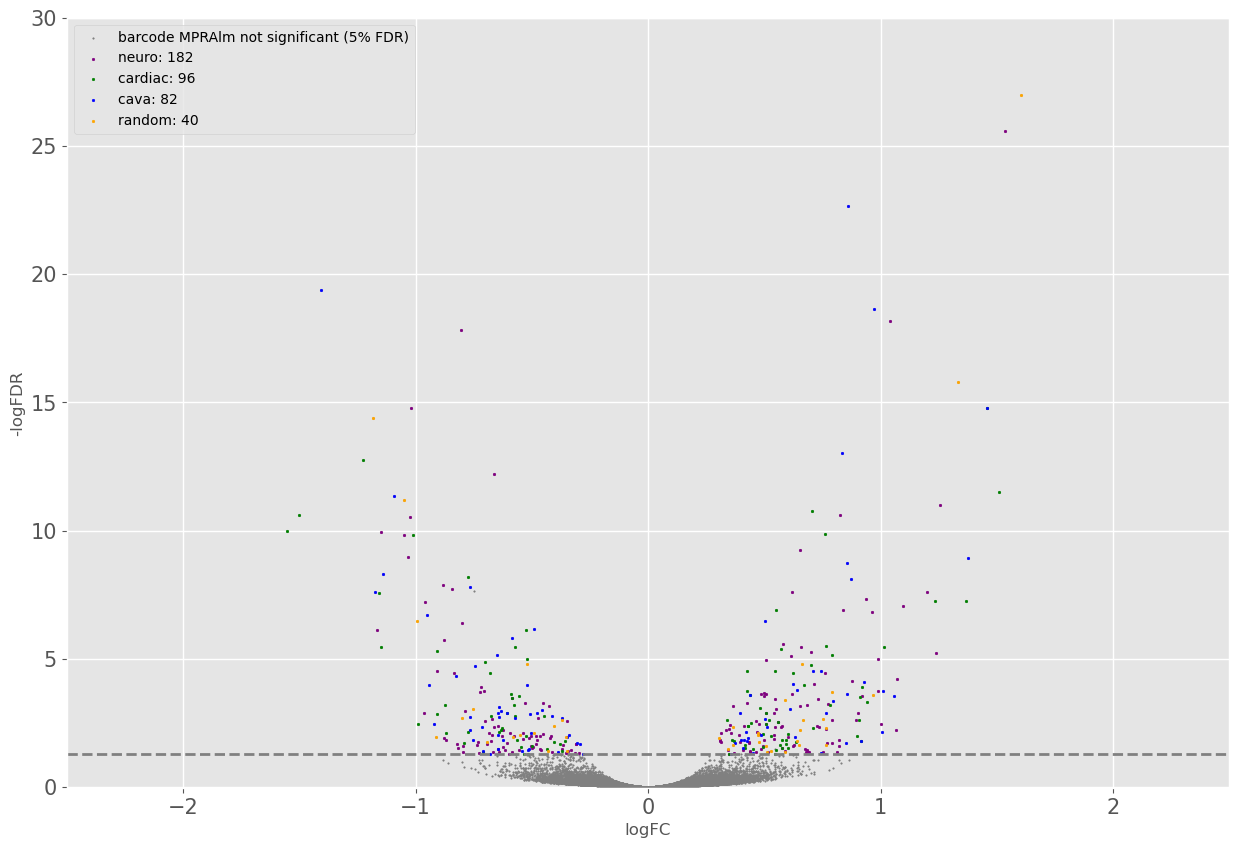

In [54]:
# plot of different types of variants: cardiac neuro random
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=neuro['logFC'],y=neuro['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"neuro: {neuro.shape[0]}",color="purple")
plt.scatter(x=cardiac['logFC'],y=cardiac['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"cardiac: {cardiac.shape[0]}",color="green")
plt.scatter(x=cava['logFC'],y=cava['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"cava: {cava.shape[0]}",color="blue")
plt.scatter(x=random['logFC'],y=random['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"random: {random.shape[0]}",color="orange")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
plt.xlim(-4,4)
plt.ylim(-0.025,4)
plt.xlim(-2.5,2.5)
plt.ylim(-0.025,30)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('mpralm_41k_results.png', transparent=True)

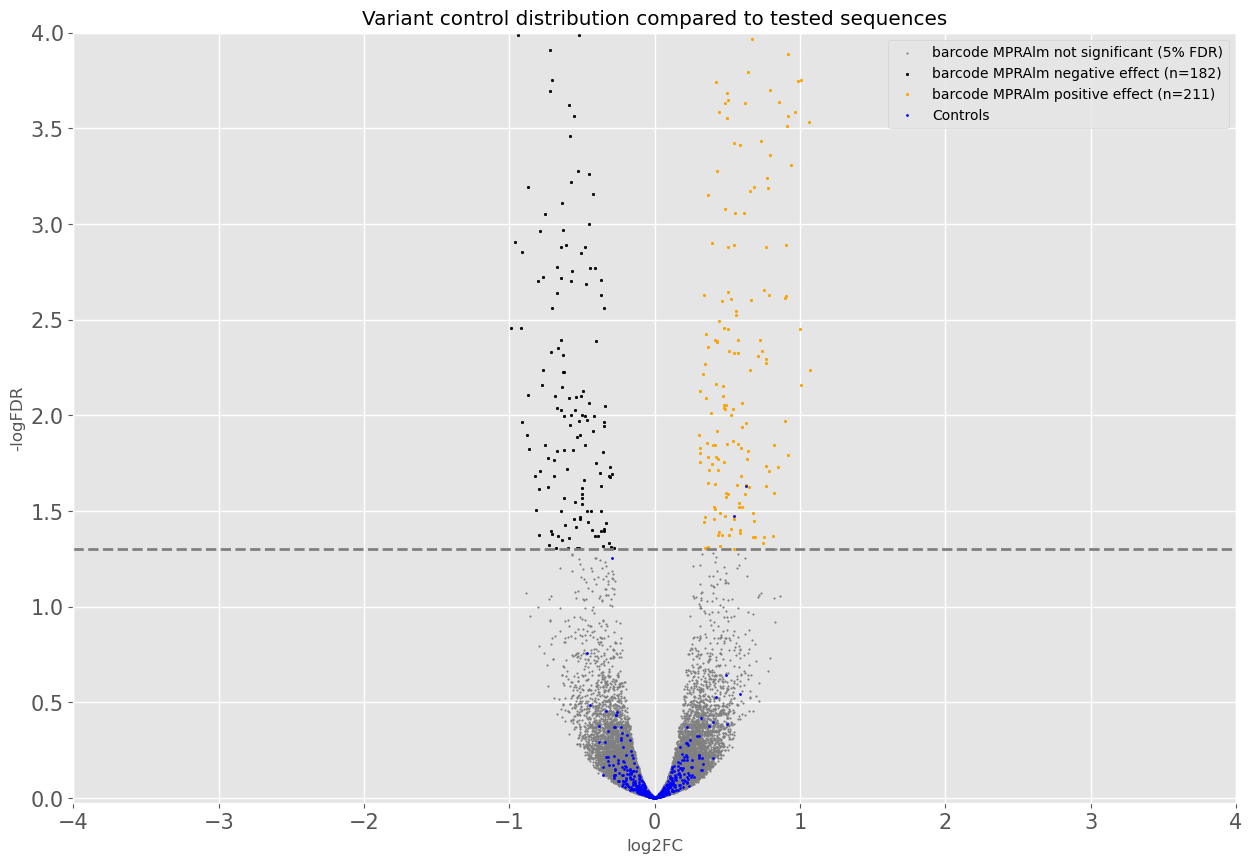

In [61]:
# make vulcano plot with coloring only controls special
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
# plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant (>{int(round(significants_niveau*100, 2))}% FDR)", color='red')
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color='gray')
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="barcode MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="barcode MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
# scatter for controls
plt.scatter(x=controls['logFC'],y=controls['adj.P.Val'].apply(lambda x:-np.log10(x)),s=2,label="Controls", color='blue')


# modify plot
plt.xlim(-4,4)
plt.ylim(-0.025,4)
# plt.xlim(-2.5,2.5)
# plt.ylim(-0.025,30)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.title("Variant control distribution compared to tested sequences")
plt.xlabel("log2FC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.show()

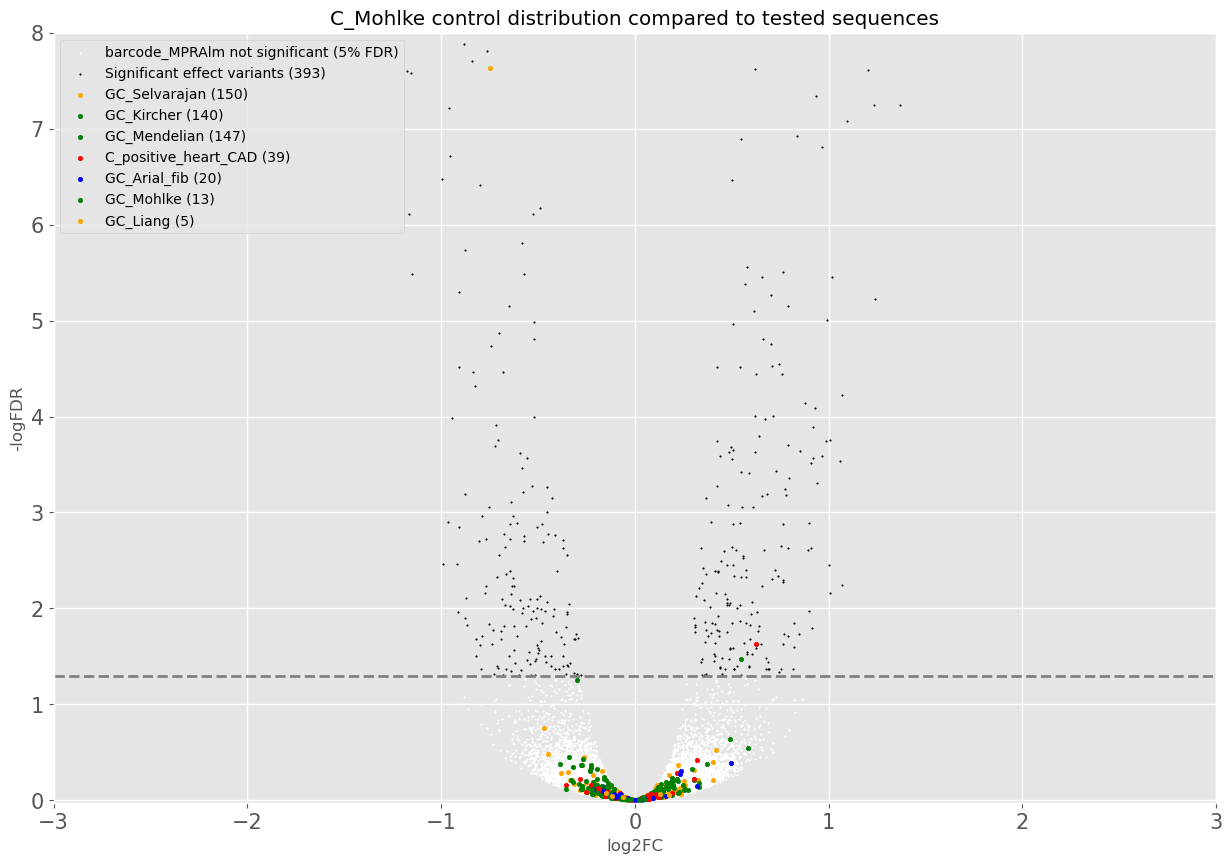

In [60]:
# make vulcano plot with coloring only controls special
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
plt.style.use("Solarize_Light2")
plt.style.use("ggplot")

plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode_MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color='white')
plt.scatter(x=significant_bcMPRAlm_table['logFC'],y=significant_bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"Significant effect variants ({significant_bcMPRAlm_table.shape[0]})", color='black')
# scatter for controls
control_dot_size = 10
# plt.scatter(x=controls['logFC'],y=controls['adj.P.Val'].apply(lambda x:-np.log10(x)),s=2,label=f"Controls ({controls.shape[0]})", color='blue')
# plt.scatter(x=c_liang['logFC'],y=c_liang['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Liang", color='orange')
# plt.scatter(x=c_selvarajan['logFC'],y=c_selvarajan['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Selvarajan", color='orange')
# plt.scatter(x=c_positive_heart_CAD['logFC'],y=c_positive_heart_CAD['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_positive_heart_CAD", color='red')
# plt.scatter(x=c_arial_fib['logFC'],y=c_arial_fib['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_Arial_fib", color='blue')
# plt.scatter(x=c_mohlke['logFC'],y=c_mohlke['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_Mohlke", color='green')
plt.scatter(x=c_selvarajan['logFC'],y=c_selvarajan['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Selvarajan ({c_selvarajan.shape[0]})", color='orange')
plt.scatter(x=c_kircher['logFC'],y=c_kircher['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Kircher ({c_kircher.shape[0]})", color='green')
plt.scatter(x=c_mendelian['logFC'],y=c_mendelian['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Mendelian ({c_mendelian.shape[0]})", color='green')
plt.scatter(x=c_positive_heart_CAD['logFC'],y=c_positive_heart_CAD['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"C_positive_heart_CAD ({c_positive_heart_CAD.shape[0]})", color='red')
plt.scatter(x=c_arial_fib['logFC'],y=c_arial_fib['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Arial_fib ({c_arial_fib.shape[0]})", color='blue')
plt.scatter(x=c_mohlke['logFC'],y=c_mohlke['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Mohlke ({c_mohlke.shape[0]})", color='green')
plt.scatter(x=c_liang['logFC'],y=c_liang['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Liang ({c_liang.shape[0]})", color='orange')

# modify plot
# plt.xlim(-4,4)
# plt.ylim(-0.025,4)
plt.xlim(-3,3)
plt.ylim(-0.025,8)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.title("C_Mohlke control distribution compared to tested sequences")
# plt.title("Variant control distribution compared to tested sequences")
plt.xlabel("log2FC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.show()


#### Controls
- investigate log2ratios of RNA/DNA for all sequences (not yet summarized over replicates)
- control list with counts:
  - MK                                     6568
  - C_positive_heart_AB                    2184
  - GC_Selvarajan                          1062
  - GC_Vista                                708
  - C_negative_heart_MK                     696
  - GC_Mendelian_variants                   612
  - C_negative_neuron_MK                    607
  - GC_Cort_Chengyu                         555
  - GC_Kircher                              547
  - C_SLEA                                  532
  - C_negative_neuron_NP                    507
  - C_positive_neuron_MK                    288
  - C_positive_neuron_NP                    283
  - C_positive_heart_CAD                    273
  - C_positive_heart_MK                     271
  - C_positive_neuron_CD                    261
  - GC_GABA_Chengyu                         214
  - GC_DNase_positive_shuffeled             159
  - GC_Atrial_fib                           135
  - GC_DNase_positive                       123
  - GC_Glut_Chengyu                          96
  - GC_Mohlke                                93
  - GC_DNase_negative_blood_shuffeled        54
  - GC_DNase_negative_brain_shuffeled        48
  - GC_Liang                                 48
  - GC_DNase_negative_blood                  45
  - GC_DNase_negative_brain                  45
  - GC_Hon                                   18

In [177]:
# investigate number of variant controls
controls_variant_map_path = config['files']['final_design']['variant_region_map_controls']
controls_variant_map = pd.read_csv(controls_variant_map_path, sep="\t")
controls_variant_map['label'] = controls_variant_map['Variant'].apply(get_label)
pd.DataFrame(controls_variant_map.groupby('label').size(), columns=['count']).reset_index()

,label,count
0,C_positive_heart_CAD,49
1,GC_Atrial_fib,23
2,GC_Kircher,198
3,GC_Liang,8
4,GC_Mendelian_variants,174
5,GC_Mohlke,20
6,GC_Selvarajan,198


In [178]:
config

{'files': {'output': {'plotting': '/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/80K_MPRA/plots/'},
  'creating': {'name_header_match': '/home/kisa/coding/80K_MPRA/80K-Analysis/05_variant_region_list/resources/id_matching_table.tsv',
   'metadata_table': '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/05_variant_region_list/resources/IGVF_metadata_table.tsv',
   'old_metadata_table': '/home/kisa/coding/80K_MPRA/80K-Analysis/05_variant_region_list/metadata_example_1903.tsv',
   'bc_MPRAlm': '/home/kisa/coding/80K_MPRA/server_results/bc_MPRAlm/toptable_GC_Selvarajan_standardNGN2.tsv',
   'control_allele_barcode_table': '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/standard_with_controls_NGN2_filtered_counts_sequences.tsv.gz',
   'toptable_bcMPRAlm': '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_standard_with_variant_controls_no_downsamplingNGN2.

In [180]:
# investigate number after filtering based on barcodes of allels (alt/ref)
control_allele_barcodes = config['files']['creating']['allele_barcode_table']
# control config['files']['creating']['control_allele_barcode_table']
c_allele_barcode_table = pd.read_csv(control_allele_barcodes, sep="\t") 
c_allele_barcode_table['label'] = c_allele_barcode_table['variant_id'].apply(get_label)
pd.DataFrame(c_allele_barcode_table.groupby('label').size(), columns=['count']).reset_index()

KeyError: 'allele_barcode_table'

In [181]:
log_ratio_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz"
log_ratio = pd.read_csv(log_ratio_path, sep="\t")
log_ratio['tmp_label'] = log_ratio['name'].apply(get_label)
log_ratio['tmp_is_control'] = log_ratio['name'].apply(is_control)
# remove no_BC row
log_ratio = log_ratio[log_ratio['name'] != 'no_BC']
log_ratio # 224010 

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,tmp_label,tmp_is_control
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106,C_SLEA,True
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99,C_SLEA,True
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68,C_SLEA,True
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89,C_SLEA,True
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54,C_SLEA,True
...,...,...,...,...,...,...,...,...,...,...,...,...
224007,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,29,24,0.087365,0.032066,0.384755,-1.377988,12,cardiac_neuro_cava_random,False
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75,cardiac_neuro_cava_random,False
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26,cardiac_neuro_cava_random,False
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29,cardiac_neuro_cava_random,False


In [182]:
log_ratio_controls = log_ratio[log_ratio['tmp_is_control']]
tested_seqs_log_ratio = log_ratio[~log_ratio['tmp_is_control']]
# groups of controls:
all_control_groups = log_ratio_controls['tmp_label'].unique()
all_control_groups
# all controls with DNase in the name used wrong coordinates in this design
wrong_coordinates_groups = [x for x in all_control_groups if "DNase" in x]
# positive controls (should show activity) (TODO: verify with MPRAlm if other controls could be used as positive controls)
# simple filter: all have "positive_neuron" in name
positive_control_groups = [x for x in all_control_groups if "positive_neuron" in x]

# negative controls (should not show activity) (negative neuron)
negative_control_groups = [x for x in all_control_groups if "negative_neuron" in x]
negative_control_groups
# #all controls with variants
# variant_control_groups = ['C_positive_heart_CAD', 'GC_Atrial_fib', 'GC_Kircher', 'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan']

shuffled_control_groups = [x for x in all_control_groups if "shuffeled" in x]

# IGVF controls:
igvf_controls = [x for x in all_control_groups if 'GC_' in x]
igvf_controls

other_controls = [x for x in all_control_groups if x not in igvf_controls and x not in positive_control_groups and x not in negative_control_groups]
other_controls
# interesting because relevant to neural or results of previous work
# interesting_controls = ['C_SLEA', 'C_positive_neuron_CD', 'GC_Atrial_fib', 'GC_Kircher', 'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan']

['C_SLEA',
 'C_negative_heart_MK',
 'C_positive_heart_AB',
 'C_positive_heart_CAD',
 'C_positive_heart_MK',
 'MK']

In [183]:
log_ratio['tmp_label'].value_counts()

tmp_label
cardiac_neuro_cava_random            206978
MK                                     6568
C_positive_heart_AB                    2184
GC_Selvarajan                          1062
GC_Vista                                708
C_negative_heart_MK                     696
GC_Mendelian_variants                   612
C_negative_neuron_MK                    607
GC_Cort_Chengyu                         555
GC_Kircher                              547
C_SLEA                                  532
C_negative_neuron_NP                    507
C_positive_neuron_MK                    288
C_positive_neuron_NP                    283
C_positive_heart_CAD                    273
C_positive_heart_MK                     271
C_positive_neuron_CD                    261
GC_GABA_Chengyu                         214
GC_DNase_positive_shuffeled             159
GC_Atrial_fib                           135
GC_DNase_positive                       123
GC_Glut_Chengyu                          96
GC_Mohlke             

In [184]:
positive_control_groups = ['C_positive_neuron_NP', 'C_positive_neuron_MK', 'C_positive_neuron_CD']
synthetic_control_groups = ['C_SLEA']
wrong_coordinates_groups = [group for group in all_control_groups if "dnase" in group.lower()] # add information that these used wrong coordinates

other_control_groups = [group for group in all_control_groups if not group in positive_control_groups]

##### Mohan normalization: take for the group you are interested the median

In [185]:
log_ratio

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,tmp_label,tmp_is_control
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106,C_SLEA,True
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99,C_SLEA,True
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68,C_SLEA,True
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89,C_SLEA,True
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54,C_SLEA,True
...,...,...,...,...,...,...,...,...,...,...,...,...
224007,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,29,24,0.087365,0.032066,0.384755,-1.377988,12,cardiac_neuro_cava_random,False
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75,cardiac_neuro_cava_random,False
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26,cardiac_neuro_cava_random,False
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29,cardiac_neuro_cava_random,False


##### positive controls:

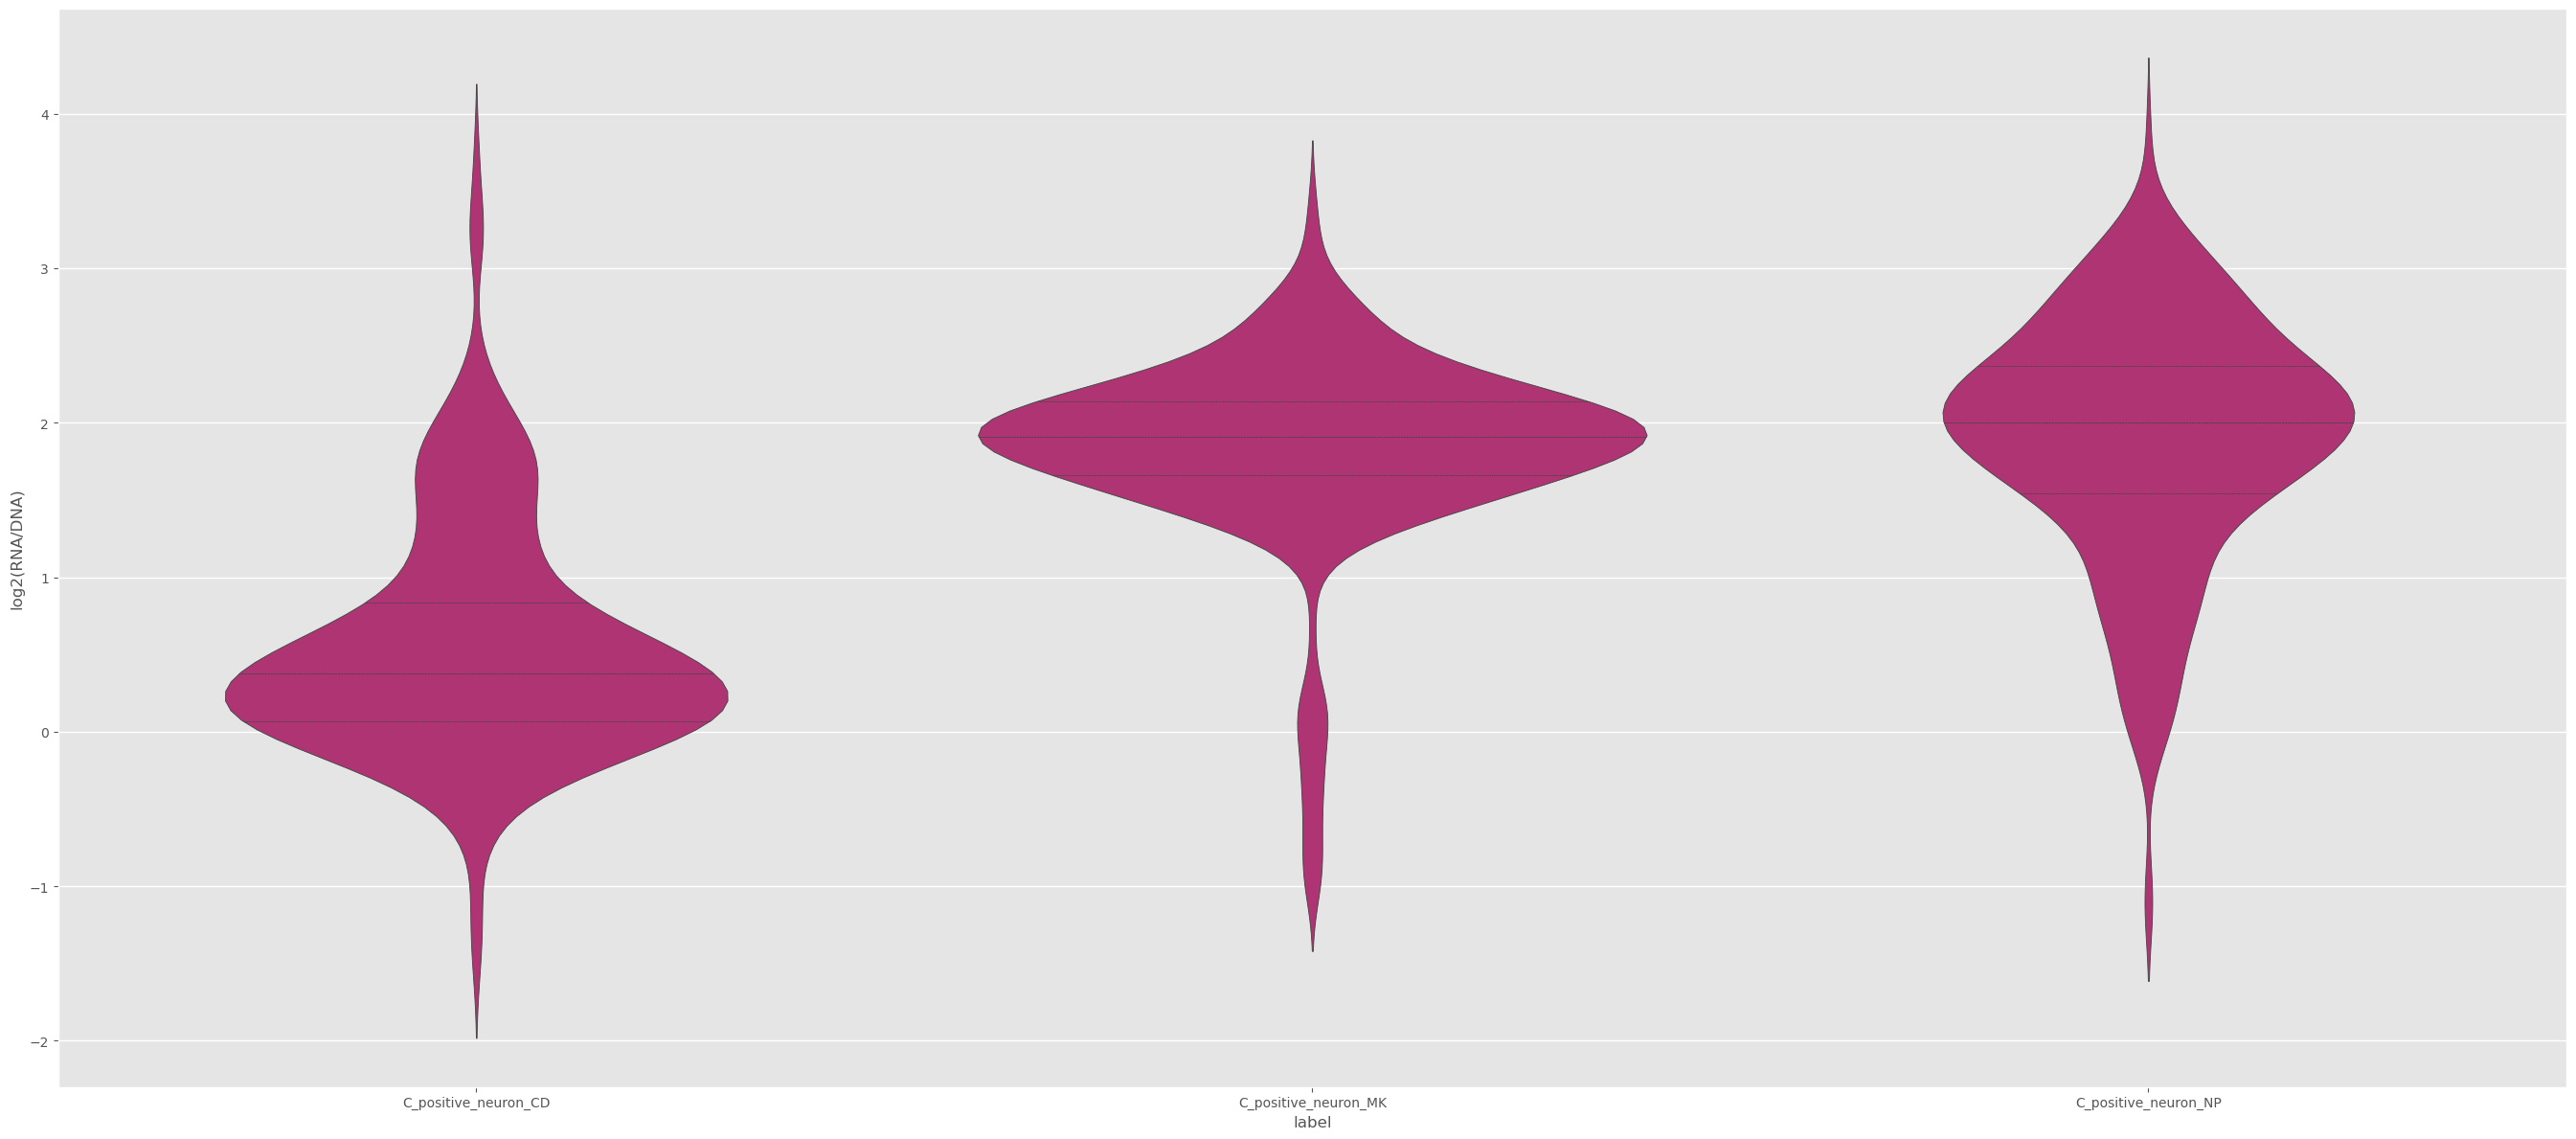

In [186]:
violin_log2_data = log_ratio[log_ratio['tmp_label'].isin(positive_control_groups)][['tmp_label', 'log2']]
# violin plot (of log2 of controls)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='tmp_label', y='log2', data=violin_log2_data, ax=ax, color='#c22075', inner='quartile')
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('log2(RNA/DNA)')

# ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()

##### negative controls

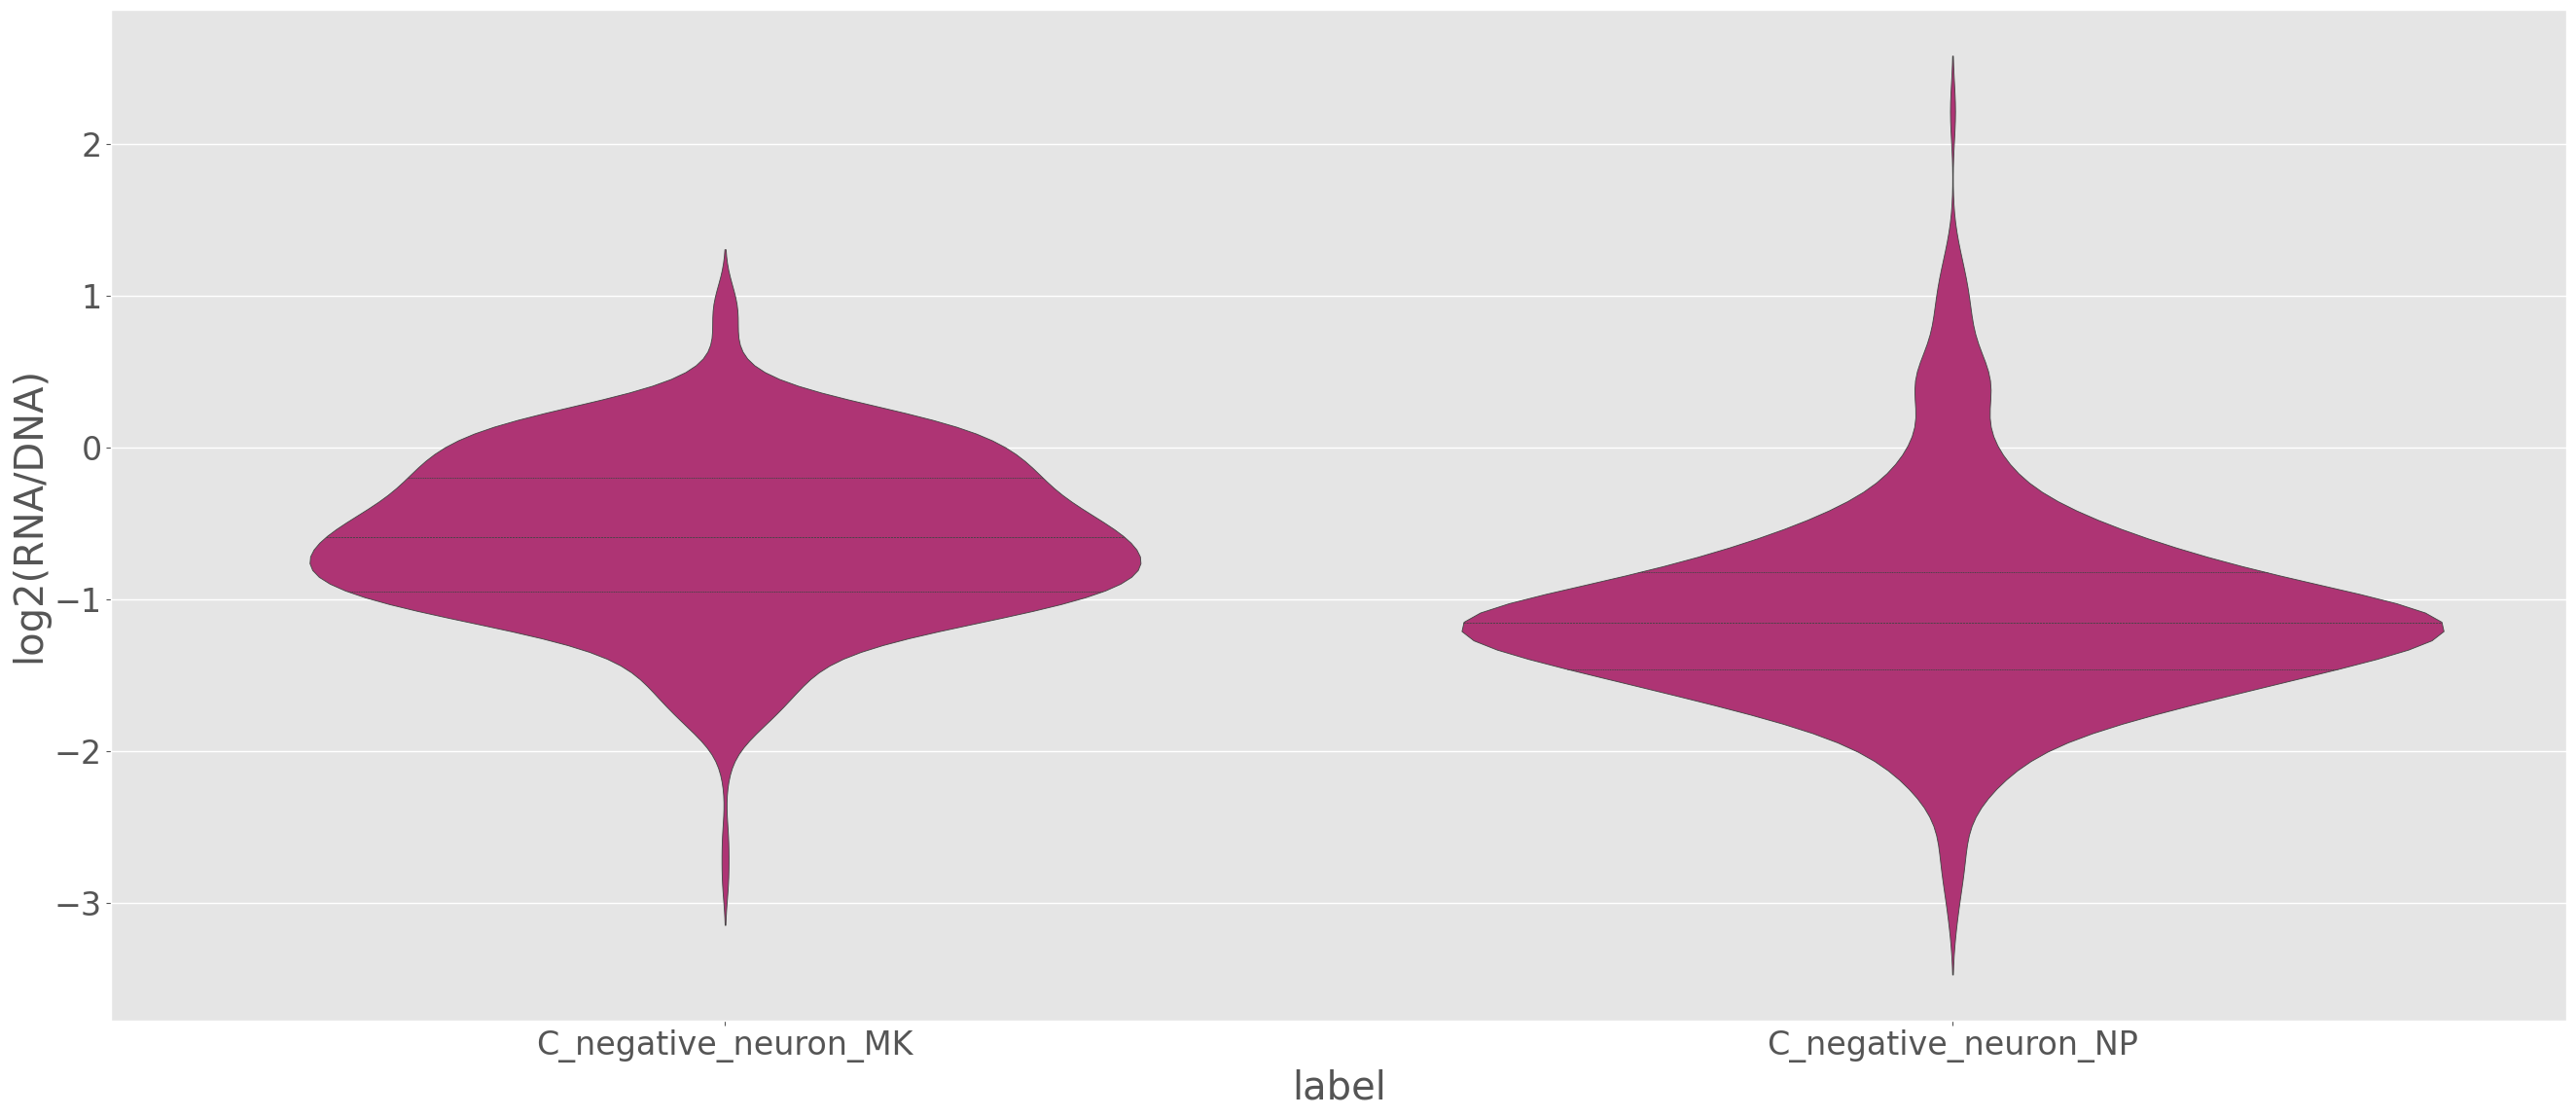

In [187]:
violin_log2_data = log_ratio[log_ratio['tmp_label'].isin(negative_control_groups)][['tmp_label', 'log2']]
# violin plot (of log2 of controls)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='tmp_label', y='log2', data=violin_log2_data, ax=ax, color='#c22075', inner='quartile')
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('log2(RNA/DNA)')
# ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()

##### comparing

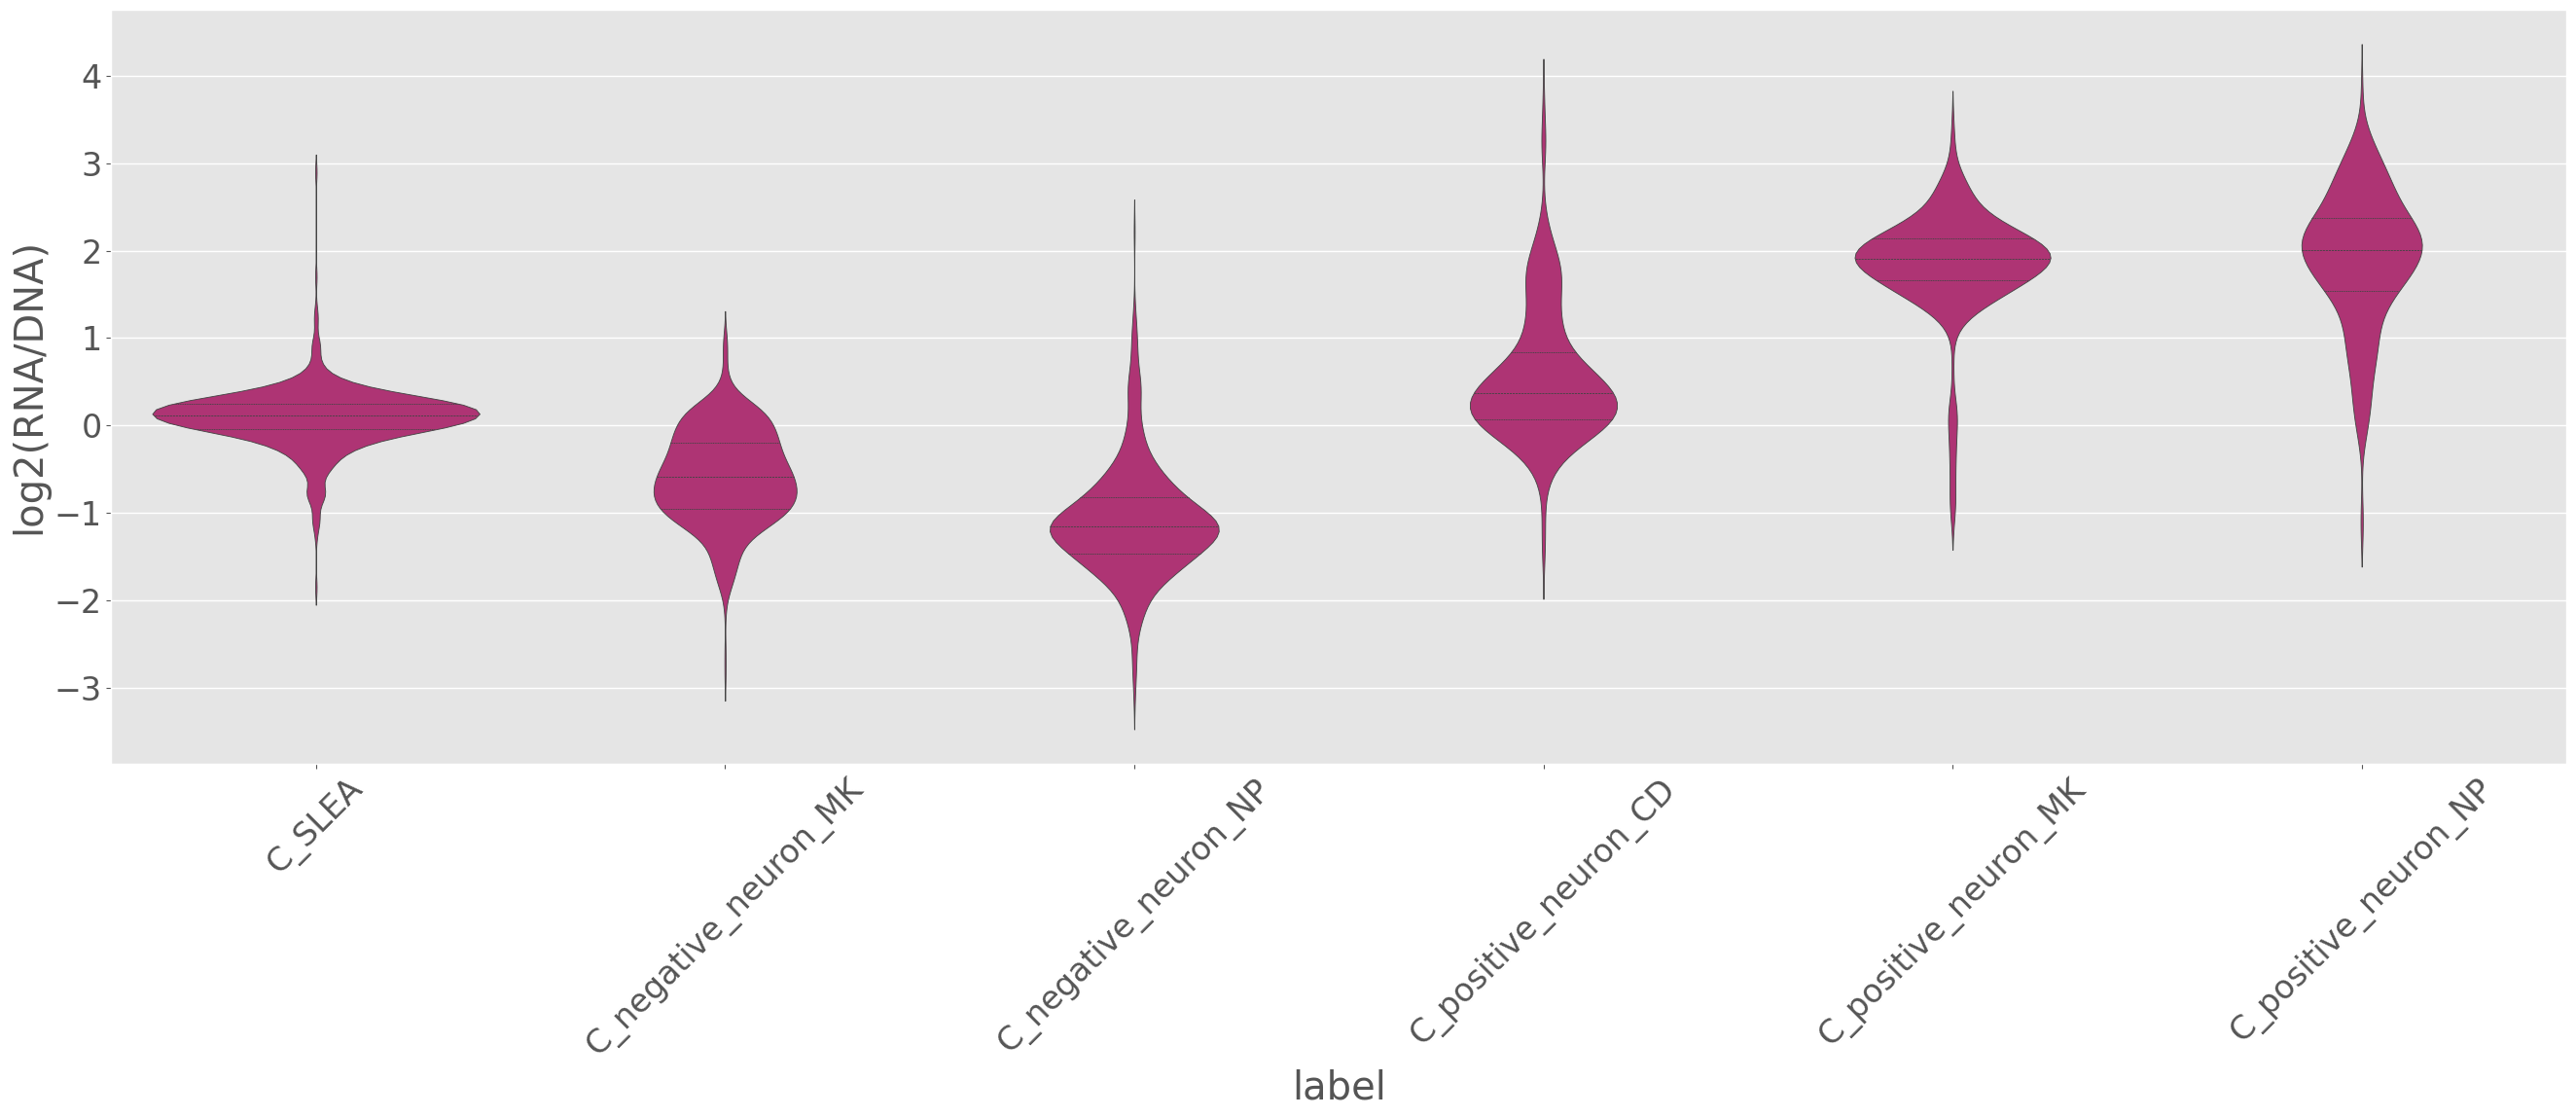

In [188]:
violin_log2_data = log_ratio[log_ratio['tmp_label'].isin(positive_control_groups + negative_control_groups + ['C_SLEA'])][['tmp_label', 'log2']]
# violin plot (of log2 of controls)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='tmp_label', y='log2', data=violin_log2_data, ax=ax, color='#c22075', inner='quartile')
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('log2(RNA/DNA)')
# ax.set_ylabel('normalized log2(RNA/DNA)')
plt.xticks(rotation=45)
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()


In [88]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,48.957326,interesting_high_log2fc,#377eb8
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.717150,interesting_high_log2fc,#377eb8
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.271528,interesting_high_log2fc,#377eb8
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,23.511906,interesting_low_pvalue,#377eb8
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.160623,interesting_high_log2fc,#377eb8
...,...,...,...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...,0.000627,uninteresting_low_log2fc,#377eb8
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...,0.000579,uninteresting_low_log2fc,#377eb8
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C,0.000579,uninteresting_low_log2fc,#377eb8
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...,0.000173,uninteresting_low_log2fc,#377eb8


In [19]:
bcMPRAlm_table['is_control'] = bcMPRAlm_table.apply(is_control, axis=1)

In [20]:
bcbcMPRAlm_table_control = bcMPRAlm_table[bcMPRAlm_table["is_control"]]
bcbcMPRAlm_table_control

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,is_control
38,-0.746661,0.617270,-6.789215,2.815750e-11,2.993647e-08,15.192563,GC_Selvarajan:rs1680636_tile1,rs1680636_tile1,7.523799,negative,True
693,0.844633,-0.033200,2.938038,3.589229e-03,1.955635e-01,-1.923092,GC_Selvarajan:rs1965983_tile1,rs1965983_tile1,0.708712,neutral,True
839,0.783773,-0.013252,2.769258,5.988302e-03,2.549270e-01,-2.321256,GC_Selvarajan:rs11084922_tile1,rs11084922_tile1,0.593584,neutral,True
849,-0.344149,-0.477969,-2.911165,3.738219e-03,1.989866e-01,-2.338997,GC_Selvarajan:rs12444333,rs12444333,0.701176,neutral,True
1208,0.422771,-0.190643,2.604528,9.552587e-03,3.151062e-01,-2.892135,GC_Selvarajan:rs2250645,rs2250645,0.501543,neutral,True
...,...,...,...,...,...,...,...,...,...,...,...
40548,-0.013047,0.149248,-0.142518,8.867091e-01,9.878068e-01,-6.621531,GC_Selvarajan:rs4846913_tile1,rs4846913_tile1,0.005328,neutral,True
41046,0.017453,-0.010929,0.211467,8.325746e-01,9.798133e-01,-6.685977,GC_Selvarajan:rs11674226_tile1,rs11674226_tile1,0.008857,neutral,True
41300,0.009792,0.080754,0.126151,8.996421e-01,9.897256e-01,-6.725342,GC_Selvarajan:rs2625259_tile2,rs2625259_tile2,0.004485,neutral,True
41335,0.010403,0.119036,0.132052,8.949741e-01,9.889736e-01,-6.728980,GC_Selvarajan:rs2625259_tile3,rs2625259_tile3,0.004815,neutral,True


In [7]:
bcMPRAlm_table['color'] = bcMPRAlm_table[['logFC', 'variant_id', 'nlog10']].apply(map_color_precise, axis=1)
bcMPRAlm_table['color'].value_counts()

# more precise split (interesting: abs(log2fc) >= 1 and nlog10 >= 2
# uninteresting_low_log2fc    40930
# interesting_low_pvalue        191
# interesting_high_log2fc       163

# normal split (interesting: abs(log2fc) >= 1 or nlog10 >= 2)
# color
# uninteresting    40930
# interesting        354

# interesting: abs(log2fc) >= 0.5 or nlog10 >= 2
# color
# uninteresting_low_log2fc    39428
# interesting_high_log2fc      1816
# interesting_low_pvalue         40

# => interesing 1856 variants

# 
# http://localhost:8888/tree?token=2c5277b673e1069ca905260d17529bb763643def53e8ed56 228

color
uninteresting_low_log2fc    41111
interesting_low_pvalue        191
interesting_high_log2fc       162
Name: count, dtype: int64

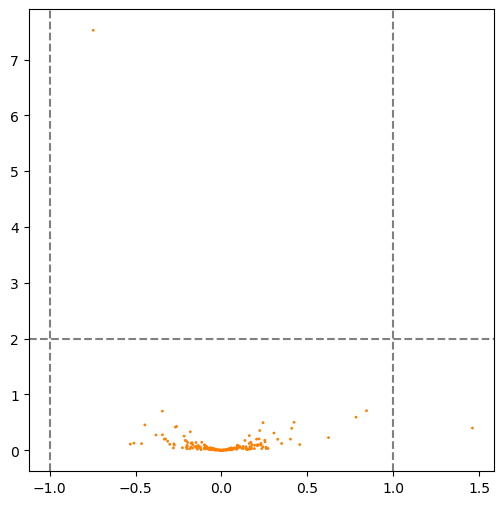

In [38]:
plt.figure(figsize=(6, 6))

plt.scatter(x=bcbcMPRAlm_table_control['logFC'],y=bcbcMPRAlm_table_control['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,color=bcbcMPRAlm_table_control['is_control'])

# plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,color=bcMPRAlm_table['is_control'])
# ax = sns.scatterplot(data=bcMPRAlm_table, x="logFC", y="nlog10", hue="is_control")
# # y-axis label: -log10(adjusted_p-value)
# ax.set(xlabel="log2FC", ylabel="−log10(adjusted p-value)")
# highlight down- or up- regulated genes
# down = bcMPRAlm_table[(bcMPRAlm_table['logFC']<=-2)&(bcMPRAlm_table['adj.P.Val']<=0.01)]
# up = bcMPRAlm_table[(bcMPRAlm_table['logFC']>=2)&(bcMPRAlm_table['adj.P.Val']<=0.01)]



plt.axvline(1,color="grey",linestyle="--")
plt.axvline(-1,color="grey",linestyle="--")
plt.axhline(2,color="grey",linestyle="--")

# ax.axhline(2, zorder = 0, c='k', ls = '--')
# ax.axvline(1, zorder = 0, c='k', ls = '--')
# ax.axvline(-1, zorder = 0, c='k', ls = '--')

In [ ]:
### better control correlation using 

In [47]:
file_path = '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/05_variant_region_list/controll_header.tsv'
control_header = pd.read_csv(file_path, sep="\t")
control_header['label'] = control_header['header'].apply(get_label)

In [51]:
def get_ratio(header):
    """'C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A::chr4:155359187-155359457-mean_ratio2.42' => 2.42"""
    return float(header.split('mean_ratio')[-1])

In [57]:
log_ratio_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz"
log_ratio = pd.read_csv(log_ratio_path, sep="\t")
log_ratio

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54
...,...,...,...,...,...,...,...,...,...,...
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29
224011,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,342,655,0.118881,0.100978,0.890402,-0.167471,104


In [73]:
pos_neuro_cd

,header,label,given_ratio,name,ratio
0,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.750000
1,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,1.507842
2,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,1.782164
3,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,2.34,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,3.090278
4,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,2.34,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,2.095457
...,...,...,...,...,...
256,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,1.271118
257,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,1.439994
258,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,1.875000
259,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,0.465657


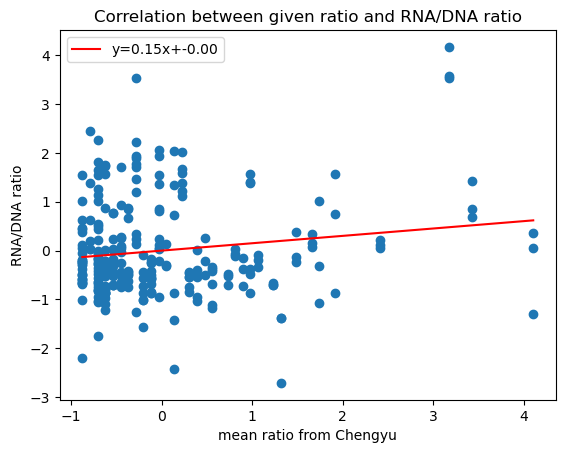

In [84]:
# pos_neuro_cd = control_header[control_header['label'] == 'C_positive_neuron_CD']
# pos_neuro_cd['given_ratio'] = pos_neuro_cd['header'].apply(get_ratio)
# pos_neuro_cd = pos_neuro_cd.merge(log_ratio[['name', 'log2']], left_on="header", right_on="name")
# correlation plot between given ratio and log2 ratio
import matplotlib.pyplot as plt
plt.scatter(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2'])
plt.xlabel("mean ratio from Chengyu")
plt.ylabel("RNA/DNA ratio")
# fit line 
import numpy as np
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2'])
line = slope*pos_neuro_cd['given_ratio']+intercept
plt.plot(pos_neuro_cd['given_ratio'], line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept))
plt.legend()
plt.title("Correlation between given ratio and RNA/DNA ratio")
plt.show()



In [ ]:
# median normalize the log2 column
log_ratio['log2'] = log_ratio['log2'] - log_ratio['log2'].median()

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pos_neuro_cd['log2'] = scaler.fit_transform(pos_neuro_cd['log2'])

# StandardScaler().fit_transform(pos_neuro_cd[['given_ratio', '']])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [83]:
pos_neuro_cd

,header,label,given_ratio,name,log2
0,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,-1.287817
1,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.049655
2,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.369771
3,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,3.427285,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,1.423937
4,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,3.427285,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,0.679918
...,...,...,...,...,...
256,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,-0.277421
257,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,-0.038520
258,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,0.467024
259,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,-2.200627


In [82]:
print(stats.pearsonr(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2']))

PearsonRResult(statistic=0.1510785243371385, pvalue=0.014562828313939583)


In [70]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,48.957326,interesting_high_log2fc,#377eb8
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.717150,interesting_high_log2fc,#377eb8
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.271528,interesting_high_log2fc,#377eb8
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,23.511906,interesting_low_pvalue,#377eb8
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.160623,interesting_high_log2fc,#377eb8
...,...,...,...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...,0.000627,uninteresting_low_log2fc,#377eb8
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...,0.000579,uninteresting_low_log2fc,#377eb8
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C,0.000579,uninteresting_low_log2fc,#377eb8
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...,0.000173,uninteresting_low_log2fc,#377eb8


In [69]:
# investigate significant results
bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < 0.05] # 390 
bcMPRAlm_table[bcMPRAlm_table['logFC'] > 1.4].shape # 11

(11, 11)

Looking into the results of the experiment:
- standard vs lowConfig: 
- correlation of DNA and RNA counts per replicate: (problem with plotting in MPRAsnakeflow)
   - DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_DNA_pairwise_minThreshold.png`
   - Ratio: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_Ratio_pairwise_minThreshold.png`
   - RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_RNA_pairwise_minThreshold.png`
- barcode: assigned counts vs all counts: correlation among replicates and count per insert distribution 
   - assigned counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - assigned counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count: DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_DNA_perBarcode.png`
   - count: RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_RNA_perBarcode.png`
   - all counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - all counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count distri DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_RNA_perBarcode.png`
   - count distri RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_DNA_perBarcode.png`


- correlation_lowconfig: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_lowConfig_barcode_RNA_pairwise.png`
   - Check up with Martin (check the exact numbers (how many are significant, how many are over log2FC))

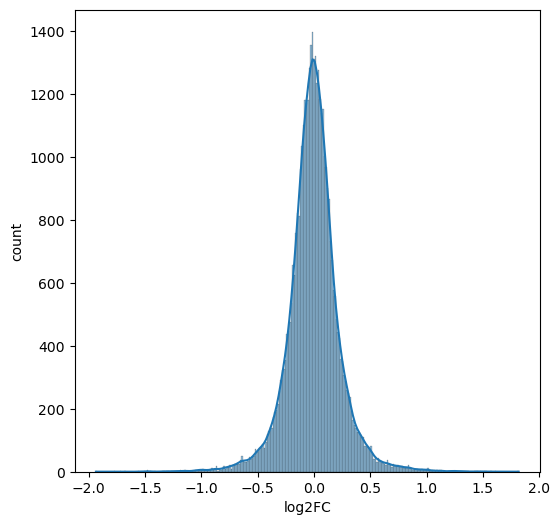

In [12]:
## log2fc distribution of our variants
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=bcMPRAlm_table, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Investigate outliers (high log2FC) and not significant
- expectation: only a few barcodes

In [14]:
# filter for high log2fc and not significant
non_sig_high_log2fc = bcMPRAlm_table[(abs(bcMPRAlm_table["logFC"]) >= 1) & (bcMPRAlm_table["adj.P.Val"] > 0.05)] # 1: 101; 0.5: 1524
len(non_sig_high_log2fc)

101

In [13]:
# number of significant variants
sig_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < 0.05]
print(len(sig_variants)) # 398

low_log2fc = bcMPRAlm_table[abs(bcMPRAlm_table["logFC"]) < 0.5]
print(len(low_log2fc)) # 39468

398
39468


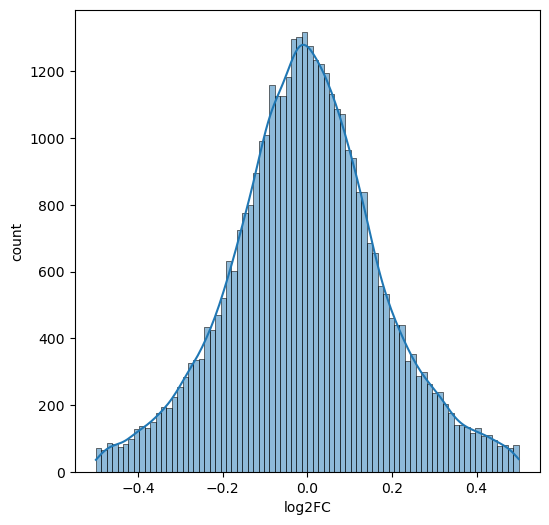

In [24]:
## log2fc distribution
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=low_log2fc, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Connect MPRA results 
- Allel Frequency (AF), Allele Count (AC)
- enformer class (high_effect, low_effect, random) 
- Gene_set (neuro, cardiac, cava, random)

In [56]:
# TODO: add connection between bc_MPRAlm_table and enformer tables
# bcMPRAlm_table
# match one enformer to the bcMPRAlm_table
# define a function for it
# does it for all enformer tables
enformer_cardiac_singleton = pd.read_csv(config["files"]["enformer_cardiac_single"], sep="\t")

In [15]:
bcMPRAlm_table.variant_id.tolist()[:10]

['cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'cardiac_neuro_cava_random:ANKZF1|ENSG00000163516.14|EH38E2076021|2-219267001-T-C',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'cardiac_neuro_cava_random:ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G',
 'cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C',
 'cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G',
 'cardiac_neuro_cava_random:SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408083-G-T',
 'cardiac_neuro_cava_random:H1-3|ENSG00000124575.7|EH38E3697725|6-26269112-G-T',
 'cardiac_neuro_cava_random:DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G']

In [57]:
enformer_cardiac_singleton.head()

,#CHROM,POS,ID,REF,ALT,DNase_max,INDEX_max,QUAL,FILTER,INFO,gene_set,variant_type,enformer_class
0,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,4254.3410,392_DNASE:CD14-positive,1,PASS,AF=6.57168e-06;AC=1,cardiac,singleton,enformer_high
1,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,4022.5996,"177_DNASE:CD8-positive,",1,PASS,AF=6.56866e-06;AC=1,cardiac,singleton,enformer_high
2,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,3591.8310,392_DNASE:CD14-positive,1,PASS,AF=6.57618e-06;AC=1,cardiac,singleton,enformer_high
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,2754.7705,401_DNASE:common myeloid,1,PASS,AF=6.56763e-06;AC=1,cardiac,singleton,enformer_high
4,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,2746.3271,392_DNASE:CD14-positive,1,PASS,AF=6.56978e-06;AC=1,cardiac,singleton,enformer_high


### Positive and Negative numbers
- Overall: 
    - standard: 41284
    - lowConfig: 42137
- Number of significant results
    - standard: 398 
    - lowConfig: 53 
    - TODO: Why do I only find 53 with p-value < 0.05?
- Plot of log2FC distribution
- Plot p-value distribution
- Table of positive and negative log2FC
- Plot of p-value distribution (adjusted p value)

In [3]:
def plot_distribution(df, value_column, n_bins=100, output_path="", title="", x_lable=None, y_lable=None):
    """Plot the distribution of the given column and store the plot in given directory"""
    plt.hist(df[value_column], bins=n_bins)
    if title != "":
        plt.title(title)
    if x_lable:
        plt.xlabel(xlabel=x_lable)
    if y_lable:
        plt.ylabel(ylabel=y_lable)
    if output_path != "":
        plt.savefig(config["plots"]["log2_p_sig_hist"])
    plt.show()
    plt.clf()

398 significant variants


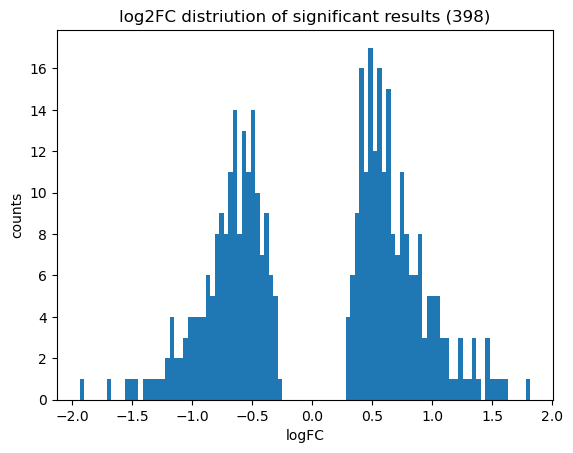

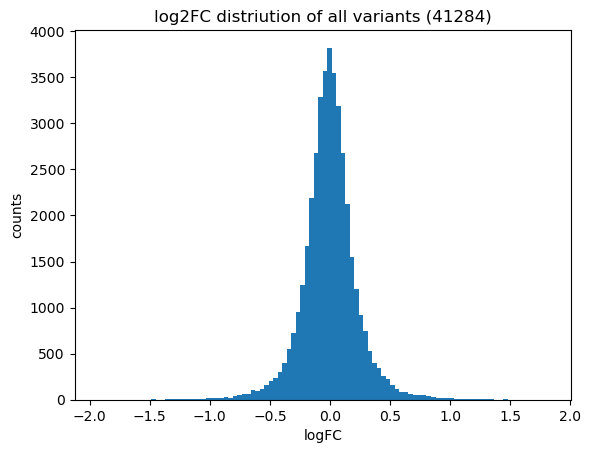

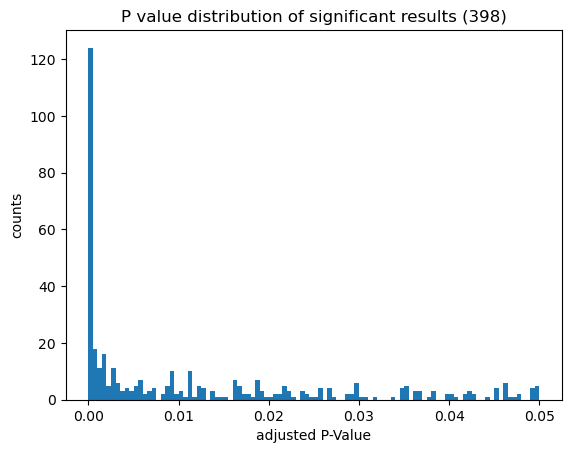

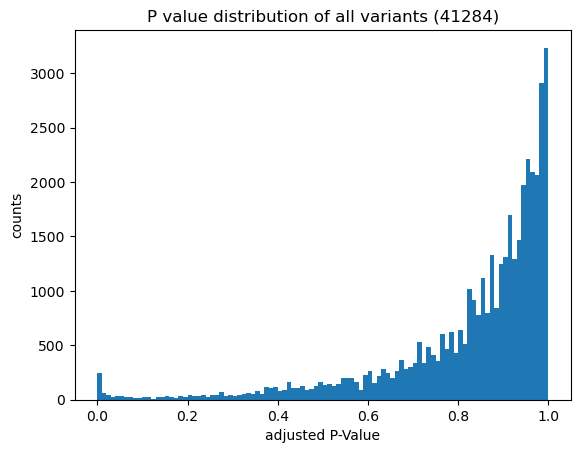

<Figure size 640x480 with 0 Axes>

In [4]:
sig_niveau = 0.05
significant_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < sig_niveau]
print("%s significant variants"%(significant_variants.shape[0]))

# plot log2FC distribution
title = "log2FC distriution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_p_sig_hist"], title=title, x_lable="logFC", y_lable="counts")
title = "log2FC distriution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_all_hist"], title=title, x_lable="logFC", y_lable="counts")

# P value distribution
title = "P value distribution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["sig_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")
title = "P value distribution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["all_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")



### Positive and negative effects
- In all variants
  - Found 20113 (0.487) positive results
  - Found 21171 (0.513) negative results
- Significant (reverse pattern => more positive than negative)
  - Found 214 (0.538) positive results
  - Found 184 (0.462) negative results

In [50]:
# number of positive negative numbers
def split_into_common_rare(df_with_AF_column,  common_threshold=0.05, column="AF"):
    """Splits df into rare and common at threshold"""
    common_vars = df_with_AF_column[df_with_AF_column[column] >= common_threshold]
    rare_vars = df_with_AF_column[df_with_AF_column[column] < common_threshold]
    print(f"Found {len(common_vars)} ({len(common_vars)/len(df_with_AF_column)}) common variants and {len(rare_vars)} ({len(rare_vars)/len(df_with_AF_column)}) rare variants with the common threshold {common_threshold}")
    ultra_rare = df_with_AF_column[df_with_AF_column[column] < 0.01]
    ultra_rare = ultra_rare[ultra_rare["AC"] != 1]
    print(f"Found {len(ultra_rare)} ultra-rare variants")
    print(f"Found {len(df_with_AF_column[df_with_AF_column['AC'] == 1])} singleton variants")
    return common_vars, rare_vars

def split_df_in_pos_neg(df_with_logFC_column, column="logFC", rounding_precision=3):
    """Splits a given data frame based on the logFC into positive and negative values"""
    positive_set = df_with_logFC_column[df_with_logFC_column[column] > 0]
    negative_set = df_with_logFC_column[df_with_logFC_column[column] < 0]
    print(f"Found {len(positive_set)} ({round(len(positive_set)/len(df_with_logFC_column),rounding_precision)}) positive results\nFound {len(negative_set)} ({round(len(negative_set)/len(df_with_logFC_column), rounding_precision)}) negative results")
    return positive_set, negative_set

In [51]:
print("In all variants")
bcMPRAlm_table_positive, bcMPRAlm_table_negative = split_df_in_pos_neg(bcMPRAlm_table)
print("Significant")
sig_positive, sig_negative = split_df_in_pos_neg(significant_variants)

In all variants
Found 20113 (0.487) positive results
Found 21171 (0.513) negative results
Significant
Found 214 (0.538) positive results
Found 184 (0.462) negative results


### Allele frequency (common: AF>1%, rare: AF=<1%, singleton: AC=0)

In [ ]:
# common rare 